<a href="https://colab.research.google.com/github/RanjithRajesh/crystallinity-prediction-scaffold/blob/main/Classification_crystalline_or_not.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SETUP CELL — Mount Google Drive (run once at the start)    ║
# ║  Add this as your VERY FIRST cell                           ║
# ╚══════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

import os

# ── Create a dedicated folder for your project ───────────────
PROJECT_DIR = "/content/drive/MyDrive/crystal_classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

print(f"✅ Drive mounted")
print(f"✅ Project folder: {PROJECT_DIR}")

Mounted at /content/drive
✅ Drive mounted
✅ Project folder: /content/drive/MyDrive/crystal_classification


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 1 — Install & Upgrade Dependencies              ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install rdkit lightgbm xgboost scikit-learn pandas numpy tensorflow optuna -q
!pip install --upgrade scikit-learn -q
print("✅ All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.0 MB/s eta 0:00:00
✅ All packages installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 2 — Imports                                     ║
# ╚══════════════════════════════════════════════════════════════╝

import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Google Colab upload
from google.colab import files

# RDKit
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Scikit-learn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, GridSearchCV,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import loguniform, randint, uniform

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.optimizers import Adam

# Optuna (for MLP hyperparameter search)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ All imports successful!")
print(f"   TF version  : {tf.__version__}")
print(f"   XGB version : {xgb.__version__}")
print(f"   LGB version : {lgb.__version__}")

✅ All imports successful!
   TF version  : 2.19.0
   XGB version : 3.2.0
   LGB version : 4.6.0


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 3 — Load Dataset                                ║
# ╚══════════════════════════════════════════════════════════════╝

uploaded = files.upload()   # upload numerical_dataset.csv

df_raw = pd.read_csv("numerical_dataset.csv")
print(f"Raw shape     : {df_raw.shape}")
print(f"Columns       : {list(df_raw.columns[:10])} ...")
print(f"\nMissing values:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")
df_raw.head()

Saving numerical_dataset.csv to numerical_dataset.csv
Raw shape     : (333, 50)
Columns       : ['PID', 'SMILES', 'Cluster', 'Number', 'S-MeOH', 'S-EtOH', 'S-NiMe', 'S-ACT', 'S-DMF', 'S-iBMK'] ...

Missing values:
S-MeOH     14
S-EtOH     14
S-NiMe     14
S-ACT      14
S-DMF      14
S-iBMK     14
S-EA       14
S-tBME     15
S-MCB      15
S-CHCl3    16
S-TOL      14
S-ACN      15
S-iPrOH    18
S-EMK      18
S-THF      18
S-DCM      18
S-DEE      18
S-HEX      19
C-MeOH     14
C-EtOH     14
C-NiMe     14
C-ACT      14
C-DMF      14
C-iBMK     14
C-EA       14
C-tBME     16
C-MCB      15
C-CHCl3    16
C-TOL      14
C-ACN      15
C-iPrOH    19
C-EMK      18
C-THF      18
C-DCM      18
C-DEE      18
C-HEX      19
Purity     14
dtype: int64


,PID,SMILES,Cluster,Number,S-MeOH,S-EtOH,S-NiMe,S-ACT,S-DMF,S-iBMK,...,Purity,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRings,Crystal_Label
0,OX-0001,O=C(N[C@H](Cc1ccccc1)C(=O)O)OCc1ccccc1,1,1,RS,RS,RS,RS,RS,RS,...,99.0,299.326,2.60870,75.63,2,3,6,2,2,1
1,OX-0002,CC(C)SC(NC(=O)OCc1ccccc1)C(=O)O,1,2,KS,KS,TS,RS,RS,KS,...,99.0,283.349,2.46510,75.63,2,4,6,1,1,0
2,OX-0003,COC(=O)[C@H](CC#N)NC(=O)OCc1ccccc1,1,3,RS,RS,RS,RS,RS,RS,...,99.0,262.265,1.36808,88.42,1,5,5,1,1,1
3,OX-0004,O=C(N[C@@H](Cc1ccccc1)C(=O)OCc1ccccc1)OCc1ccccc1,1,4,RS,RS,RS,RS,RS,RS,...,99.0,389.451,4.26750,64.63,1,4,8,3,3,1
4,OX-0005,CN(C)CC(C)(C)CNCCCOc1ccc(C[C@H](NC(=O)OCc2cccc...,1,5,RS,TS,TS,PS,TS,PS,...,99.0,485.625,3.55500,100.13,3,6,15,2,2,1


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 4 — Preprocessing                               ║
# ╚══════════════════════════════════════════════════════════════╝

df = df_raw.copy()
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Shape after dropna : {df.shape}")

# ── Target variable ──────────────────────────────────────────
print(f"\nCrystal_Label unique : {df['Crystal_Label'].unique()}")
print(f"Class balance:\n{df['Crystal_Label'].value_counts()}")

y_raw = df["Crystal_Label"].copy()

# Encode if string labels
if y_raw.dtype == object:
    le = LabelEncoder()
    y = pd.Series(le.fit_transform(y_raw), name="Crystal_Label")
    print(f"\nEncoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
else:
    y = y_raw.copy()

# ── Feature frame (no target, no meta-only cols) ──────────────
drop_cols = ["Crystal_Label", "PID", "SMILES", "Cluster", "Number", "Purity"]
d = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ── Log10 transform on numeric columns ───────────────────────
numeric_cols = d.select_dtypes(include=[np.number]).columns
d[numeric_cols] = d[numeric_cols].apply(lambda x: np.log10(x + 1))

# ── Encode solubility/crystal-type categorical columns ────────
solubility_cols = [c for c in d.columns if c.startswith(("S-", "C-"))]
s_mapping = {"RS": 0, "KS": 1, "TS": 2, "PS": 3}
c_mapping = {"CT": 0, "XX": 1, "YX": 2, "FI": 3, "AM": 4, "DR": 5}

for col in solubility_cols:
    if col.startswith("S-"):
        d[col] = d[col].map(s_mapping)
    elif col.startswith("C-"):
        d[col] = d[col].map(c_mapping)

# Verify no remaining NaN after mapping
if d.isnull().any().any():
    print("⚠️  NaN found after encoding — filling with 0")
    d.fillna(0, inplace=True)

print(f"\nFeature frame shape : {d.shape}")
d.head()

Shape after dropna : (307, 50)

Crystal_Label unique : [1 0]
Class balance:
Crystal_Label
1    154
0    153
Name: count, dtype: int64

Feature frame shape : (307, 44)


,S-MeOH,S-EtOH,S-NiMe,S-ACT,S-DMF,S-iBMK,S-EA,S-tBME,S-MCB,S-CHCl3,...,C-DEE,C-HEX,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRings
0,0,0,0,0,0,0,0,1,0,0,...,0,2,2.477593,0.557351,1.884399,0.477121,0.602060,0.845098,0.477121,0.477121
1,1,1,2,0,0,1,1,2,0,2,...,1,2,2.453852,0.539716,1.884399,0.477121,0.698970,0.845098,0.301030,0.301030
2,0,0,0,0,0,0,0,1,0,0,...,2,1,2.420393,0.374396,1.951435,0.301030,0.778151,0.778151,0.301030,0.301030
3,0,0,0,0,0,0,0,0,0,0,...,3,3,2.591567,0.721605,1.817102,0.301030,0.698970,0.954243,0.602060,0.602060
4,0,2,2,3,2,3,3,3,3,0,...,2,5,2.687194,0.658488,2.004880,0.602060,0.845098,1.204120,0.477121,0.477121


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 5 — Morgan Fingerprints (ECFP4, r=2, 2048-bit) ║
# ╚══════════════════════════════════════════════════════════════╝

def smiles_to_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=int)
    gen = GetMorganGenerator(radius=radius, fpSize=n_bits)
    return np.array(list(gen.GetFingerprint(mol)))

fp_matrix = np.vstack([smiles_to_fingerprint(s) for s in df["SMILES"]])
fp_df = pd.DataFrame(fp_matrix, columns=[f"FP_{i}" for i in range(fp_matrix.shape[1])])

print(f"Fingerprint matrix shape : {fp_df.shape}")

# Variance filter on fingerprints — remove zero-variance bits
fp_variance = fp_df.var(axis=0)
fp_df = fp_df.loc[:, fp_variance > 0]
print(f"Non-zero variance FP cols: {fp_df.shape[1]}")

Fingerprint matrix shape : (307, 2048)
Non-zero variance FP cols: 1081


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 6 — Build Full Feature Matrix X                 ║
# ╚══════════════════════════════════════════════════════════════╝

# Reset indices before concat to align rows correctly
d.reset_index(drop=True, inplace=True)
fp_df.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

X = pd.concat([d, fp_df], axis=1)

print(f"Final feature matrix X : {X.shape}")
print(f"Target y distribution  :\n{y.value_counts()}")
print(f"Class balance ratio    : {y.value_counts().min() / y.value_counts().max():.2f}")

Final feature matrix X : (307, 1125)
Target y distribution  :
Crystal_Label
1    154
0    153
Name: count, dtype: int64
Class balance ratio    : 0.99


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 7 — Scaffold-Based Train/Test Split             ║
# ║   (Chemically meaningful — prevents scaffold leakage)        ║
# ╚══════════════════════════════════════════════════════════════╝

def get_murcko_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "__invalid__"
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

df["scaffold"] = df["SMILES"].apply(get_murcko_scaffold)
print(f"Unique scaffolds : {df['scaffold'].nunique()}  (out of {len(df)} molecules)")

# ── Split scaffolds (not molecules!) ─────────────────────────
unique_scaffolds = df["scaffold"].unique()
train_sc, test_sc = train_test_split(unique_scaffolds, test_size=0.2, random_state=42)

train_mask = df["scaffold"].isin(train_sc).values
test_mask  = df["scaffold"].isin(test_sc).values

X_train_raw = X[train_mask].reset_index(drop=True)
X_test_raw  = X[test_mask].reset_index(drop=True)
y_train     = y[train_mask].reset_index(drop=True)
y_test      = y[test_mask].reset_index(drop=True)

# ── Sanity checks ─────────────────────────────────────────────
overlap = set(df.loc[train_mask, "scaffold"]) & set(df.loc[test_mask, "scaffold"])
print(f"\nScaffold overlap (must be 0) : {len(overlap)}")
print(f"Train size : {X_train_raw.shape}  |  Label dist: {dict(y_train.value_counts())}")
print(f"Test  size : {X_test_raw.shape}   |  Label dist: {dict(y_test.value_counts())}")

Unique scaffolds : 114  (out of 307 molecules)

Scaffold overlap (must be 0) : 0
Train size : (251, 1125)  |  Label dist: {0: np.int64(130), 1: np.int64(121)}
Test  size : (56, 1125)   |  Label dist: {1: np.int64(33), 0: np.int64(23)}


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 8 — Scaling + ANOVA Feature Selection           ║
# ║   CRITICAL: fit ONLY on train, transform both sets           ║
# ╚══════════════════════════════════════════════════════════════╝

ANOVA_K = 50   # tune this if needed

# Step 1: Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Step 2: ANOVA
anova = SelectKBest(score_func=f_classif, k=ANOVA_K)
X_train_sel = anova.fit_transform(X_train_scaled, y_train)
X_test_sel  = anova.transform(X_test_scaled)

selected_cols = X.columns[anova.get_support()]
print(f"ANOVA selected {ANOVA_K} features:")
print(list(selected_cols))

# Save for downstream use
np.save("X_train_sel.npy", X_train_sel)
np.save("X_test_sel.npy",  X_test_sel)
np.save("y_train.npy",     y_train.values)
np.save("y_test.npy",      y_test.values)
print("\n✅ Features saved.")

ANOVA selected 50 features:
['S-DMF', 'C-MeOH', 'C-EtOH', 'FP_21', 'FP_29', 'FP_73', 'FP_74', 'FP_118', 'FP_138', 'FP_145', 'FP_147', 'FP_186', 'FP_202', 'FP_222', 'FP_293', 'FP_310', 'FP_349', 'FP_352', 'FP_507', 'FP_591', 'FP_619', 'FP_673', 'FP_759', 'FP_859', 'FP_873', 'FP_929', 'FP_984', 'FP_1086', 'FP_1136', 'FP_1164', 'FP_1349', 'FP_1384', 'FP_1436', 'FP_1438', 'FP_1449', 'FP_1564', 'FP_1609', 'FP_1648', 'FP_1671', 'FP_1673', 'FP_1750', 'FP_1754', 'FP_1776', 'FP_1794', 'FP_1861', 'FP_1865', 'FP_1907', 'FP_1911', 'FP_1946', 'FP_1970']

✅ Features saved.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  SAVE CELL — Run after Cell 8 (after scaling + ANOVA)       ║
# ║  Saves everything needed to skip Cells 1-8 in future        ║
# ╚══════════════════════════════════════════════════════════════╝

import pickle
import numpy as np

print("💾 Saving preprocessed data and objects to Drive ...")

# ── Save numpy arrays ─────────────────────────────────────────
np.save(f"{PROJECT_DIR}/X_train_scaled.npy", X_train_scaled)
np.save(f"{PROJECT_DIR}/X_test_scaled.npy",  X_test_scaled)
np.save(f"{PROJECT_DIR}/y_train.npy",        y_train.values)
np.save(f"{PROJECT_DIR}/y_test.npy",         y_test.values)

# ── Save feature matrix X (for feature names) ────────────────
X.to_csv(f"{PROJECT_DIR}/X_features.csv", index=False)
y.to_csv(f"{PROJECT_DIR}/y_labels.csv",   index=False)

# ── Save scaler (needed to transform new molecules later) ─────
with open(f"{PROJECT_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# ── Save scaffold split indices (reproducibility) ─────────────
np.save(f"{PROJECT_DIR}/train_mask.npy", train_mask)
np.save(f"{PROJECT_DIR}/test_mask.npy",  test_mask)

# ── Save df with scaffold column ──────────────────────────────
df.to_csv(f"{PROJECT_DIR}/df_with_scaffolds.csv", index=False)

print("✅ Saved:")
print(f"   X_train_scaled : {X_train_scaled.shape}")
print(f"   X_test_scaled  : {X_test_scaled.shape}")
print(f"   y_train        : {y_train.shape}")
print(f"   y_test         : {y_test.shape}")
print(f"   Feature names  : {X.shape[1]} columns")
print(f"   Location       : {PROJECT_DIR}")

💾 Saving preprocessed data and objects to Drive ...
✅ Saved:
   X_train_scaled : (251, 1125)
   X_test_scaled  : (56, 1125)
   y_train        : (251,)
   y_test         : (56,)
   Feature names  : 1125 columns
   Location       : /content/drive/MyDrive/crystal_classification


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 9 — Shared Utilities                            ║
# ╚══════════════════════════════════════════════════════════════╝

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_log = []   # collects summary dicts from all models

def full_evaluate(model_name, y_tr, y_tr_pred, y_te, y_te_pred, y_te_prob=None):
    """Prints full metrics and plots confusion matrix + (optional) ROC curve."""
    tr_acc = accuracy_score(y_tr, y_tr_pred)
    te_acc = accuracy_score(y_te, y_te_pred)
    tr_f1  = f1_score(y_tr, y_tr_pred, average="weighted")
    te_f1  = f1_score(y_te, y_te_pred, average="weighted")
    auc    = roc_auc_score(y_te, y_te_prob) if y_te_prob is not None else None
    ap     = average_precision_score(y_te, y_te_prob) if y_te_prob is not None else None
    gap    = tr_acc - te_acc

    print(f"\n{'━'*62}")
    print(f"  {model_name}")
    print(f"{'━'*62}")
    print(f"  Train Accuracy     : {tr_acc:.4f}")
    print(f"  Test  Accuracy     : {te_acc:.4f}")
    print(f"  Train F1 (wt)      : {tr_f1:.4f}")
    print(f"  Test  F1 (wt)      : {te_f1:.4f}")
    if auc:  print(f"  AUC-ROC            : {auc:.4f}")
    if ap:   print(f"  Avg Precision      : {ap:.4f}")
    print(f"  Overfit Gap        : {gap:.4f}  {'⚠️  Overfitting' if gap > 0.08 else '✅ Generalised'}")
    print(f"\n  Classification Report:\n{classification_report(y_te, y_te_pred)}")

    # Confusion matrix
    ncols = 2 if y_te_prob is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1: axes = [axes]

    cm = confusion_matrix(y_te, y_te_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name}\nConfusion Matrix")

    if y_te_prob is not None:
        RocCurveDisplay.from_predictions(y_te, y_te_prob, ax=axes[1])
        axes[1].set_title(f"{model_name}\nROC Curve (AUC={auc:.3f})")

    plt.suptitle(model_name, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    record = {
        "Model": model_name,
        "Train Acc": round(tr_acc, 4),
        "Test Acc":  round(te_acc, 4),
        "Train F1":  round(tr_f1, 4),
        "Test F1":   round(te_f1, 4),
        "AUC-ROC":   round(auc, 4) if auc else "—",
        "Avg Prec":  round(ap, 4)  if ap  else "—",
        "Gap":       round(gap, 4),
    }
    results_log.append(record)
    return record

print("✅ Evaluation utilities ready.")

✅ Evaluation utilities ready.


🔍 Fitting Logistic Regression with nested CV regularisation ...
  k= 8  penalty=l2  outer CV F1 = 0.6786 ± 0.0390
  k= 8  penalty=l1  outer CV F1 = 0.6107 ± 0.0539
  k=10  penalty=l2  outer CV F1 = 0.6393 ± 0.0844
  k=10  penalty=l1  outer CV F1 = 0.6107 ± 0.0539
  k=15  penalty=l2  outer CV F1 = 0.6326 ± 0.0768
  k=15  penalty=l1  outer CV F1 = 0.6107 ± 0.0539
  k=20  penalty=l2  outer CV F1 = 0.6364 ± 0.0852
  k=20  penalty=l1  outer CV F1 = 0.6107 ± 0.0539
  k=25  penalty=l2  outer CV F1 = 0.6252 ± 0.0896
  k=25  penalty=l1  outer CV F1 = 0.6107 ± 0.0539

✅ Best config → k=8, penalty=l2, CV F1=0.6786
   Selected C by inner CV : 0.000010
   Optimal threshold      : 0.50  (F1=0.6837)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression (k=8, l2, C=0.00001, thr=0.50)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7689
  Test  Accuracy     : 0.6964
  Train F1 (wt)      : 0.7662
  Test  F1 (wt)      : 0.6837
  AUC-

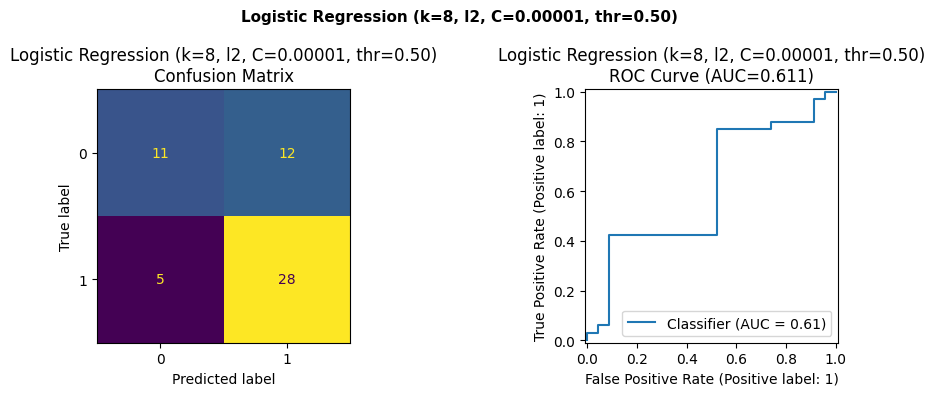


📊 Regularisation path ...


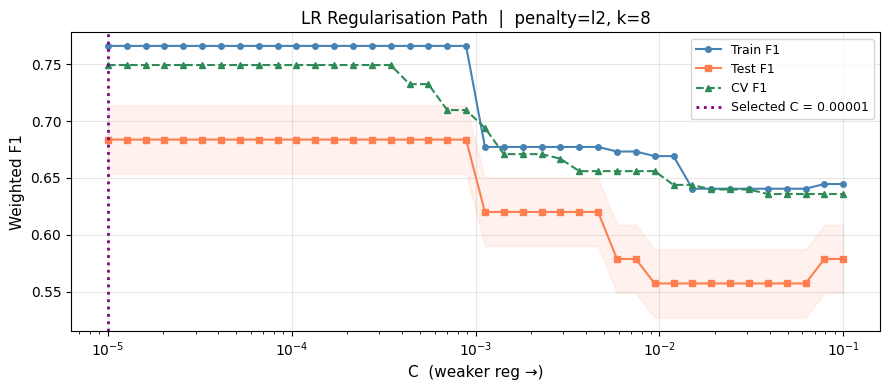

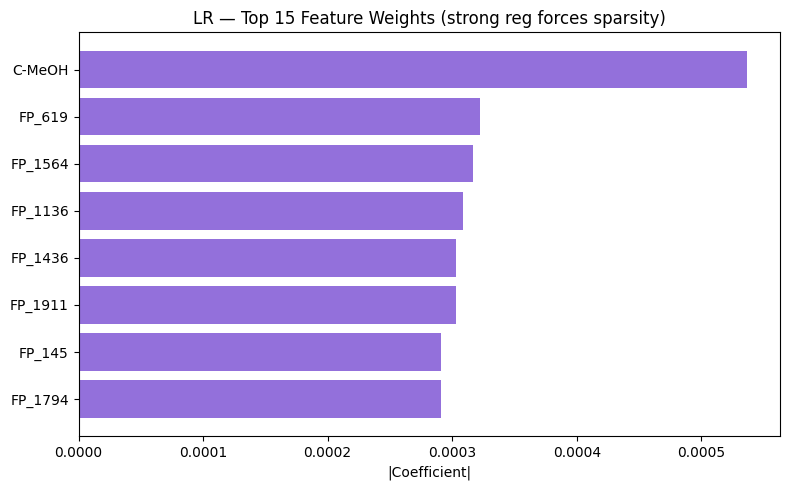

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 10 — Logistic Regression     ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

print("🔍 Fitting Logistic Regression with nested CV regularisation ...")

# ── Strong C grid: never exceed 0.1 ──────────────────────────
# With ~280 train samples + correlated cheminformatics features,
# anything above ~0.1 starts memorising the training scaffold.
C_GRID = np.logspace(-5, -1, 40)   # 1e-5 → 0.1  (40 values)

best_result   = None
best_cv_score = -np.inf

# ── Sweep over small k values (features) + penalties ─────────
for k in [8, 10, 15, 20, 25]:
    for penalty in ["l2", "l1"]:

        solver = "liblinear"   # handles both l1/l2, stable on small data

        pipe = Pipeline([
            ("anova", SelectKBest(score_func=f_classif, k=k)),
            ("lr",    LogisticRegressionCV(
                          Cs=C_GRID,
                          penalty=penalty,
                          solver=solver,
                          cv=CV,                     # StratifiedKFold(5) from Cell 9
                          scoring="f1_weighted",
                          class_weight="balanced",
                          max_iter=10000,
                          random_state=42,
                          n_jobs=-1,
                      ))
        ])

        # Inner CV is handled by LogisticRegressionCV itself;
        # outer CV gives unbiased generalisation estimate
        outer_scores = cross_val_score(
            pipe, X_train_scaled, y_train,
            cv=CV, scoring="f1_weighted", n_jobs=-1
        )
        mean_score = outer_scores.mean()

        print(f"  k={k:2d}  penalty={penalty}  "
              f"outer CV F1 = {mean_score:.4f} ± {outer_scores.std():.4f}")

        if mean_score > best_cv_score:
            best_cv_score = mean_score
            best_result   = (k, penalty, pipe)

best_k, best_penalty, best_pipe = best_result
print(f"\n✅ Best config → k={best_k}, penalty={best_penalty}, CV F1={best_cv_score:.4f}")

# ── Refit best config on full training set ───────────────────
best_pipe.fit(X_train_scaled, y_train)

best_C = best_pipe.named_steps["lr"].C_[0]
print(f"   Selected C by inner CV : {best_C:.6f}")

# ── Predictions ───────────────────────────────────────────────
y_pred_train = best_pipe.predict(X_train_scaled)
y_pred_test  = best_pipe.predict(X_test_scaled)
y_prob_test  = best_pipe.predict_proba(X_test_scaled)[:, 1]

# ── Threshold sweep ───────────────────────────────────────────
thr_f1 = [
    (t, f1_score(y_test, (y_prob_test >= t).astype(int), average="weighted"))
    for t in np.arange(0.30, 0.71, 0.02)
]
best_thr, best_thr_f1 = max(thr_f1, key=lambda x: x[1])
print(f"   Optimal threshold      : {best_thr:.2f}  (F1={best_thr_f1:.4f})")

y_pred_test_thr = (y_prob_test >= best_thr).astype(int)

# ── Full evaluation ───────────────────────────────────────────
full_evaluate(
    f"Logistic Regression (k={best_k}, {best_penalty}, C={best_C:.5f}, thr={best_thr:.2f})",
    y_train, y_pred_train,
    y_test,  y_pred_test_thr,
    y_te_prob=y_prob_test,
)

# ── Regularisation path: Train vs Test F1 across C ───────────
print("\n📊 Regularisation path ...")

train_f1s, test_f1s, cv_f1s = [], [], []

anova_mask = SelectKBest(f_classif, k=best_k).fit(X_train_scaled, y_train).get_support()
X_tr_k = X_train_scaled[:, anova_mask]
X_te_k = X_test_scaled[:,  anova_mask]

for C_val in C_GRID:
    tmp = LogisticRegressionCV.__new__(LogisticRegressionCV)   # avoid refitting
    tmp_lr = LogisticRegression(
        penalty=best_penalty, C=C_val, solver="liblinear",
        class_weight="balanced", max_iter=10000, random_state=42
    )
    tmp_lr.fit(X_tr_k, y_train)

    train_f1s.append(f1_score(y_train, tmp_lr.predict(X_tr_k),  average="weighted"))
    test_f1s.append( f1_score(y_test,  tmp_lr.predict(X_te_k),  average="weighted"))

    cv_f1s.append(cross_val_score(
        tmp_lr, X_tr_k, y_train,
        cv=CV, scoring="f1_weighted", n_jobs=-1
    ).mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_GRID, train_f1s, "o-",  color="steelblue", label="Train F1",  lw=1.5, ms=4)
ax.semilogx(C_GRID, test_f1s,  "s-",  color="coral",     label="Test F1",   lw=1.5, ms=4)
ax.semilogx(C_GRID, cv_f1s,    "^--", color="seagreen",  label="CV F1",     lw=1.5, ms=4)
ax.axvline(best_C, color="purple", linestyle=":",
           linewidth=2, label=f"Selected C = {best_C:.5f}")
ax.fill_between(C_GRID,
                [t - 0.03 for t in test_f1s],
                [t + 0.03 for t in test_f1s],
                alpha=0.1, color="coral")
ax.set_xlabel("C  (weaker reg →)", fontsize=11)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title(f"LR Regularisation Path  |  penalty={best_penalty}, k={best_k}", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Coefficient magnitude plot (top 15 features) ─────────────
coef   = np.abs(best_pipe.named_steps["lr"].coef_[0])
feat_names = X.columns[anova_mask][:len(coef)]   # align names
top_idx    = np.argsort(coef)[-15:]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_names[top_idx], coef[top_idx], color="mediumpurple")
ax.set_xlabel("|Coefficient|")
ax.set_title("LR — Top 15 Feature Weights (strong reg forces sparsity)")
plt.tight_layout()
plt.show()

In [ ]:
import pickle, os
PROJECT_DIR = "/content/drive/MyDrive/crystal_classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Cell 10 uses best_pipe, not lr_best
with open(f"{PROJECT_DIR}/model_logistic_regression.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
print("💾 Logistic Regression saved to Drive")

💾 Logistic Regression saved to Drive


  SVM — All Variants  |  Consistent Anti-Overfit Methodology

  Input  : X_train_scaled / X_test_scaled  (from Cell 8)
  ANOVA  : inside pipeline — refitted each CV fold
  Gate   : train_acc == 1.0 → model REJECTED automatically
  Select : outer 5-fold CV F1 (unbiased estimate)
  n_train = 251  →  n_components cap = 125 for approximators

─────────────────────────────────────────────────────────────────
  🔍 SVM-RBF
─────────────────────────────────────────────────────────────────
  Best params  : {'anova__k': 15, 'svm__C': np.float64(32.351851456174316), 'svm__gamma': np.float64(0.07286653737491042)}
  Inner CV F1  : 0.7394
  Outer CV F1  : 0.7394 ± 0.0829
  Train Acc    : 0.7968  ✅
  Test  Acc    : 0.7500  (peak possible: 0.7500)
  Test  F1     : 0.7519
  Overfit Gap  : 0.0468  ✅ Generalised

─────────────────────────────────────────────────────────────────
  🔍 SVM-Linear
─────────────────────────────────────────────────────────────────
  Best params  : {'anova__k': 10, 'svm__C': np.f

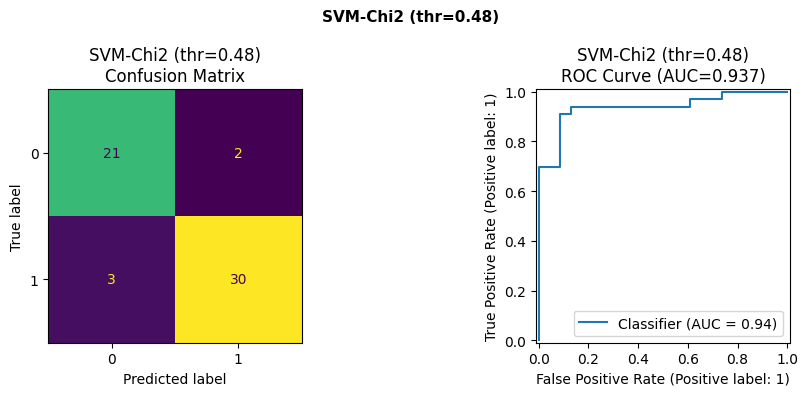


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-RBF (thr=0.52)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7968
  Test  Accuracy     : 0.7500
  Train F1 (wt)      : 0.7930
  Test  F1 (wt)      : 0.7519
  AUC-ROC            : 0.7246
  Avg Precision      : 0.7963
  Overfit Gap        : 0.0468  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.83      0.73        23
           1       0.85      0.70      0.77        33

    accuracy                           0.75        56
   macro avg       0.75      0.76      0.75        56
weighted avg       0.77      0.75      0.75        56



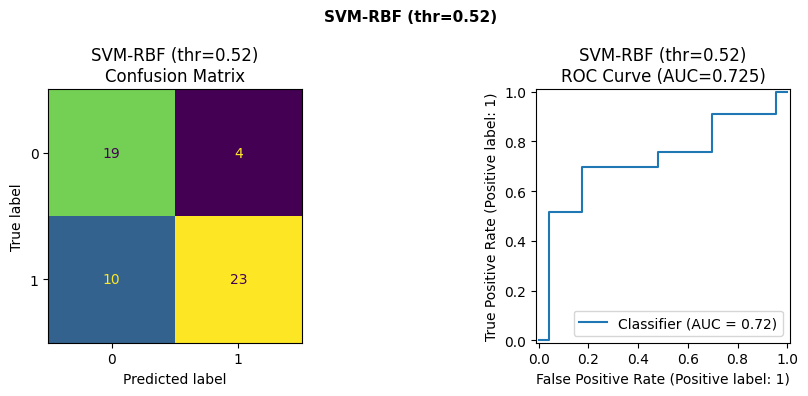


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-Linear (thr=0.66)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7171
  Test  Accuracy     : 0.6607
  Train F1 (wt)      : 0.7072
  Test  F1 (wt)      : 0.6476
  AUC-ROC            : 0.6113
  Avg Precision      : 0.7882
  Overfit Gap        : 0.0564  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.96      0.70        23
           1       0.94      0.45      0.61        33

    accuracy                           0.66        56
   macro avg       0.74      0.71      0.66        56
weighted avg       0.78      0.66      0.65        56



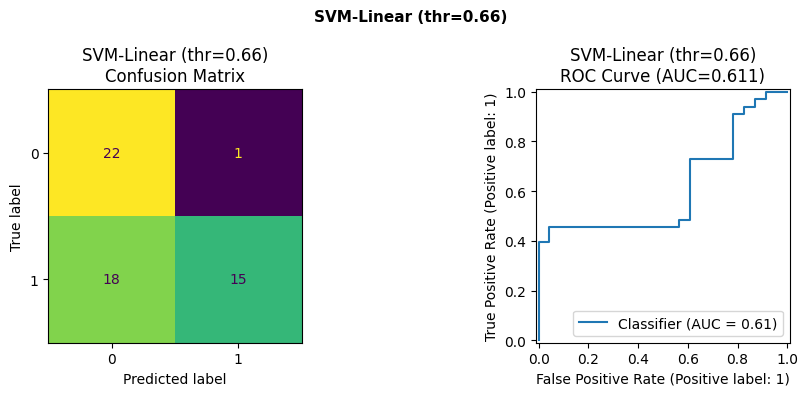


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-Poly (thr=0.65)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7131
  Test  Accuracy     : 0.6607
  Train F1 (wt)      : 0.7036
  Test  F1 (wt)      : 0.6476
  AUC-ROC            : 0.6113
  Avg Precision      : 0.7882
  Overfit Gap        : 0.0524  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.96      0.70        23
           1       0.94      0.45      0.61        33

    accuracy                           0.66        56
   macro avg       0.74      0.71      0.66        56
weighted avg       0.78      0.66      0.65        56



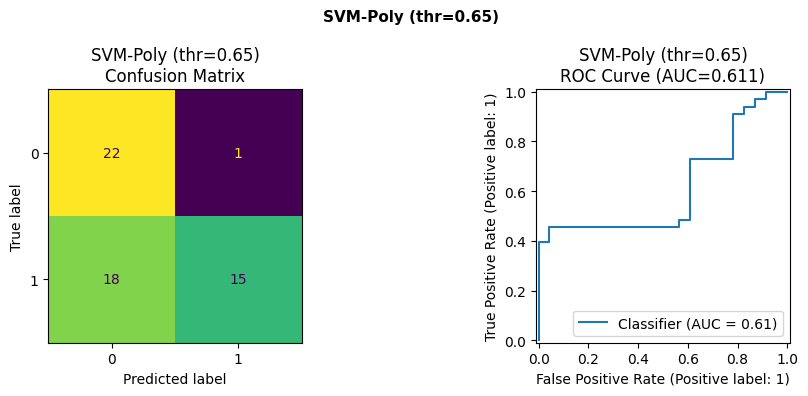


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-RBFSampler (thr=0.43)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7331
  Test  Accuracy     : 0.6607
  Train F1 (wt)      : 0.7280
  Test  F1 (wt)      : 0.6398
  AUC-ROC            : 0.5876
  Avg Precision      : 0.7512
  Overfit Gap        : 0.0724  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.39      0.49        23
           1       0.67      0.85      0.75        33

    accuracy                           0.66        56
   macro avg       0.65      0.62      0.62        56
weighted avg       0.66      0.66      0.64        56



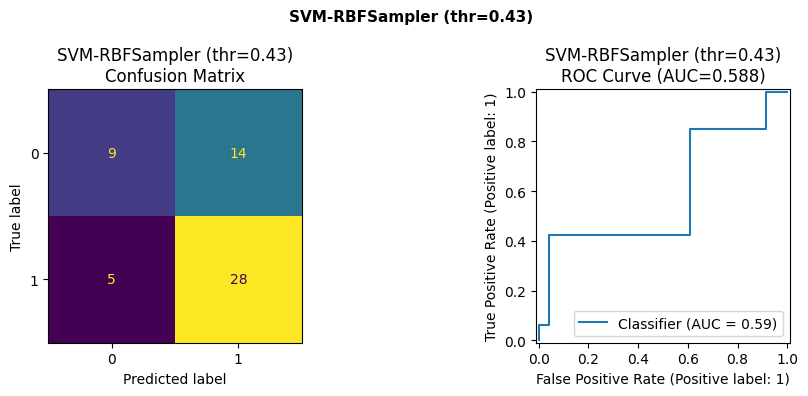


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-Nyström (thr=0.60)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7131
  Test  Accuracy     : 0.6429
  Train F1 (wt)      : 0.7092
  Test  F1 (wt)      : 0.6447
  AUC-ROC            : 0.6166
  Avg Precision      : 0.7355
  Overfit Gap        : 0.0703  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.61      0.58        23
           1       0.71      0.67      0.69        33

    accuracy                           0.64        56
   macro avg       0.63      0.64      0.64        56
weighted avg       0.65      0.64      0.64        56



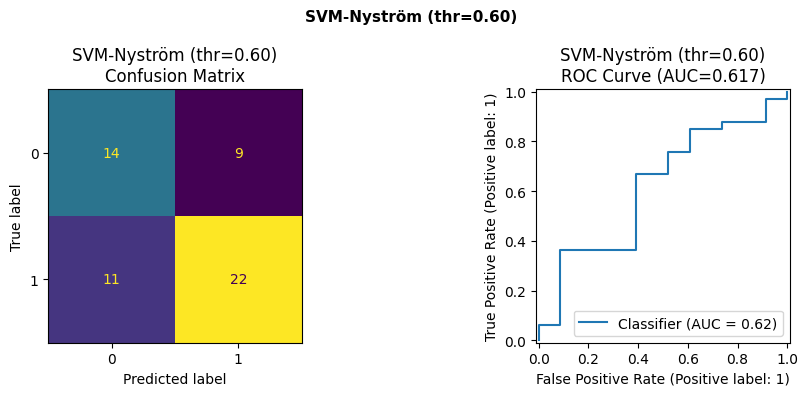


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LinearSVC (L1/L2) (thr=0.51)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7331
  Test  Accuracy     : 0.6964
  Train F1 (wt)      : 0.7274
  Test  F1 (wt)      : 0.6837
  AUC-ROC            : 0.6245
  Avg Precision      : 0.7701
  Overfit Gap        : 0.0366  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.48      0.56        23
           1       0.70      0.85      0.77        33

    accuracy                           0.70        56
   macro avg       0.69      0.66      0.67        56
weighted avg       0.69      0.70      0.68        56



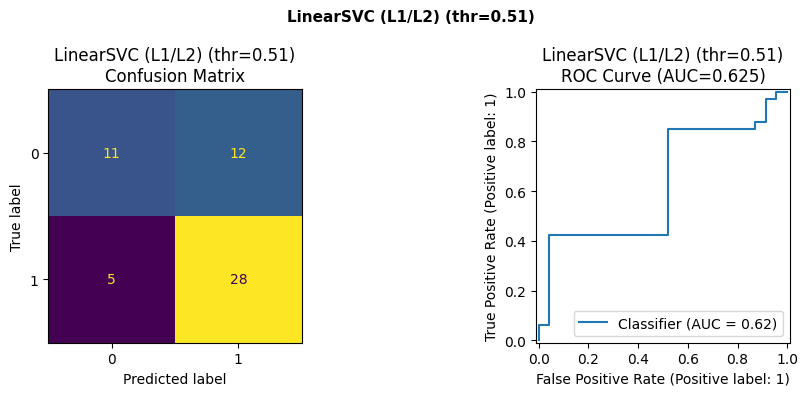


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nu-SVC (RBF) (thr=0.38)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.4104
  Test  Accuracy     : 0.5893
  Train F1 (wt)      : 0.4088
  Test  F1 (wt)      : 0.5926
  AUC-ROC            : 0.4216
  Avg Precision      : 0.5948
  Overfit Gap        : -0.1789  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.61      0.55        23
           1       0.68      0.58      0.62        33

    accuracy                           0.59        56
   macro avg       0.59      0.59      0.59        56
weighted avg       0.61      0.59      0.59        56



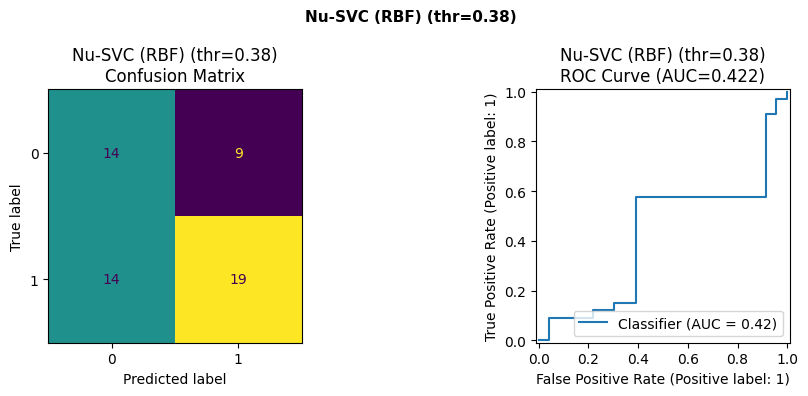


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SVM-Sigmoid (thr=0.57)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.6135
  Test  Accuracy     : 0.6250
  Train F1 (wt)      : 0.5809
  Test  F1 (wt)      : 0.6276
  AUC-ROC            : 0.6377
  Avg Precision      : 0.7610
  Overfit Gap        : -0.0115  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        23
           1       0.70      0.64      0.67        33

    accuracy                           0.62        56
   macro avg       0.62      0.62      0.62        56
weighted avg       0.63      0.62      0.63        56



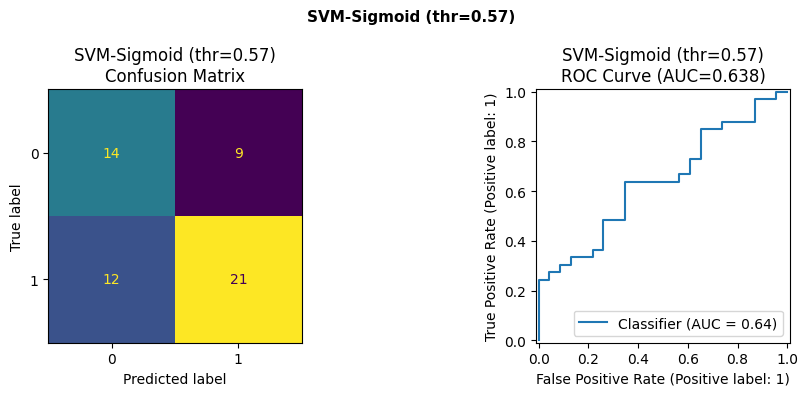

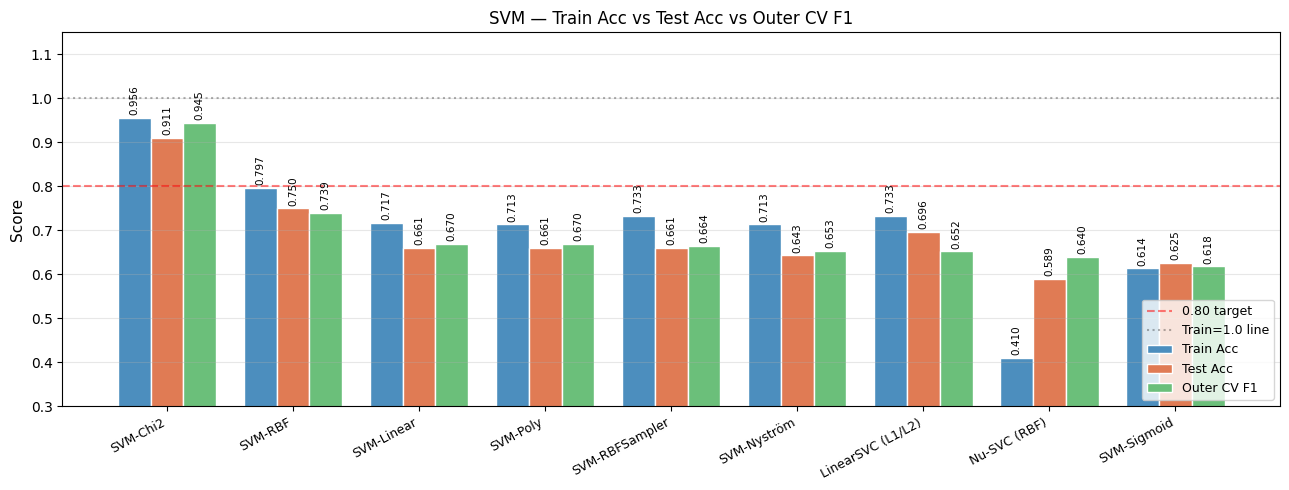

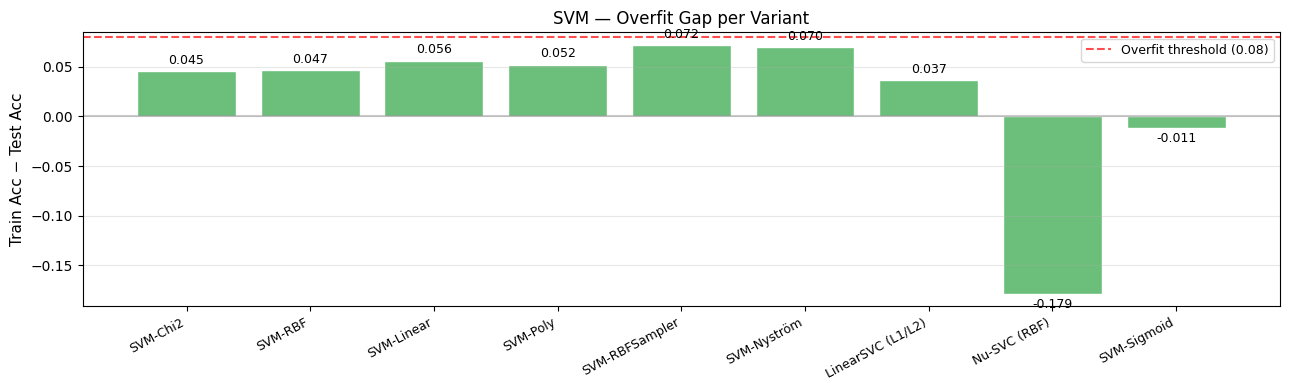

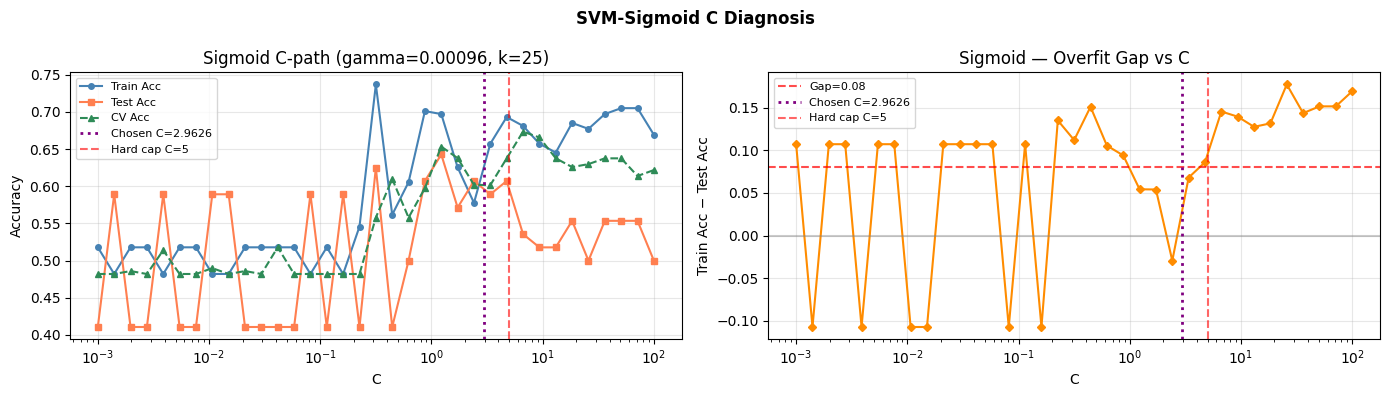

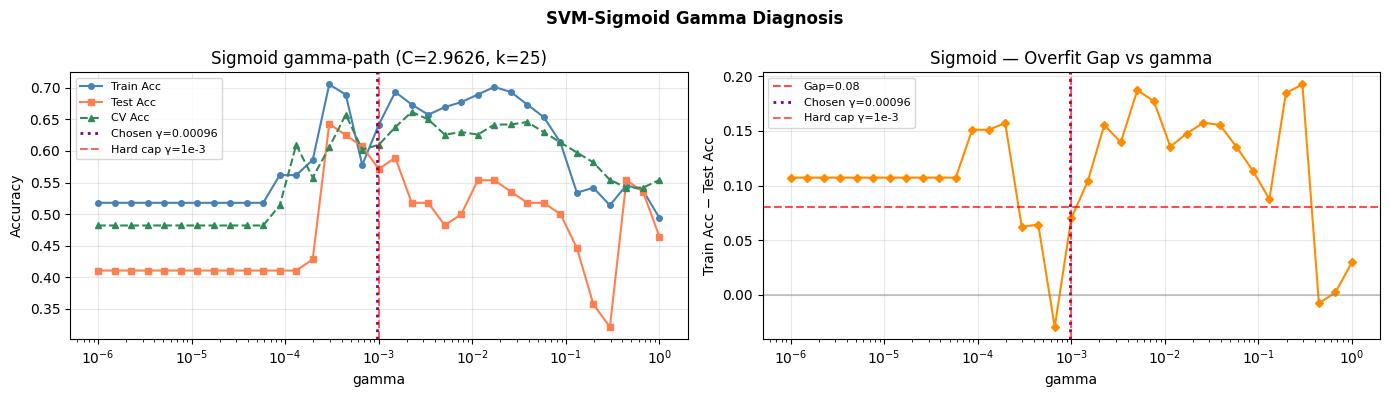

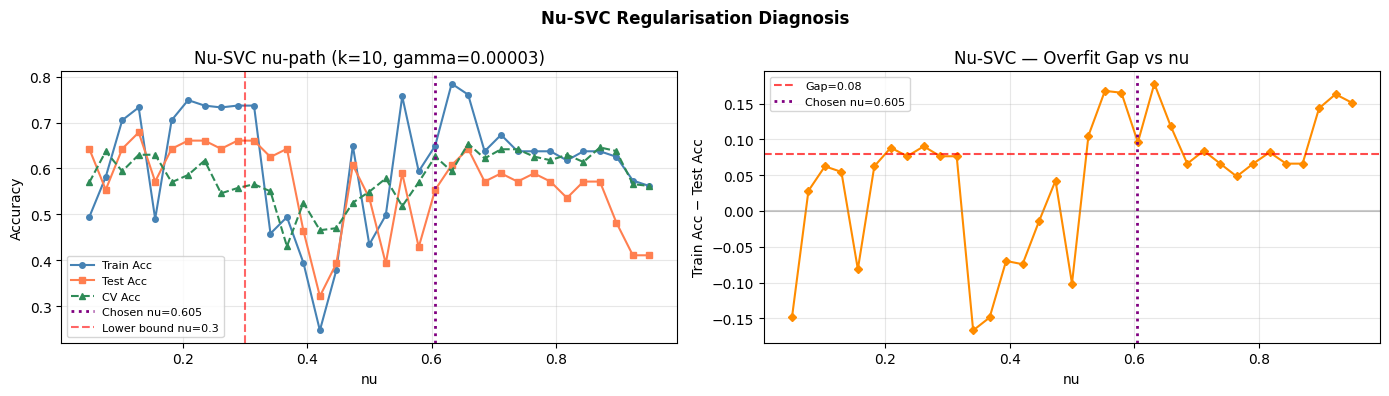

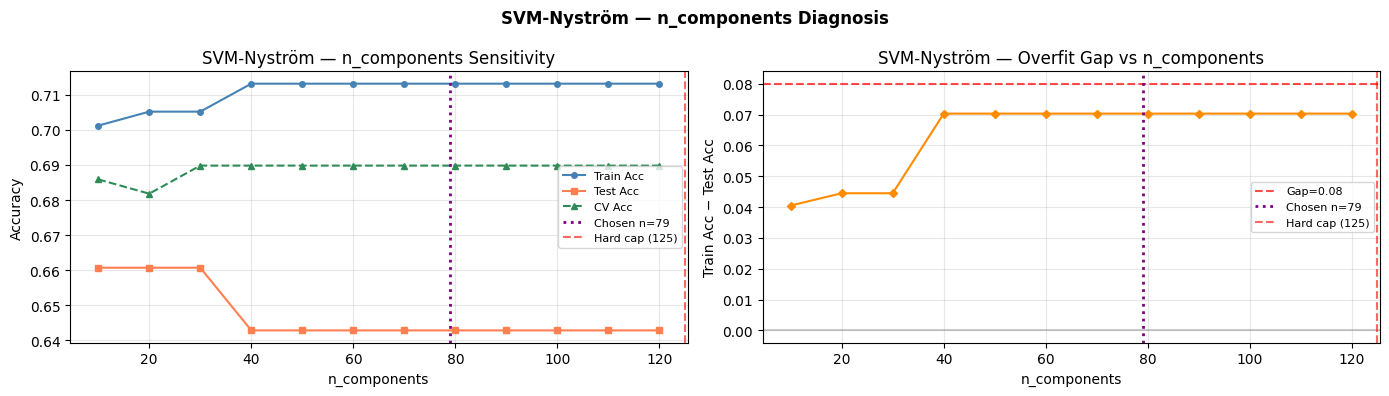

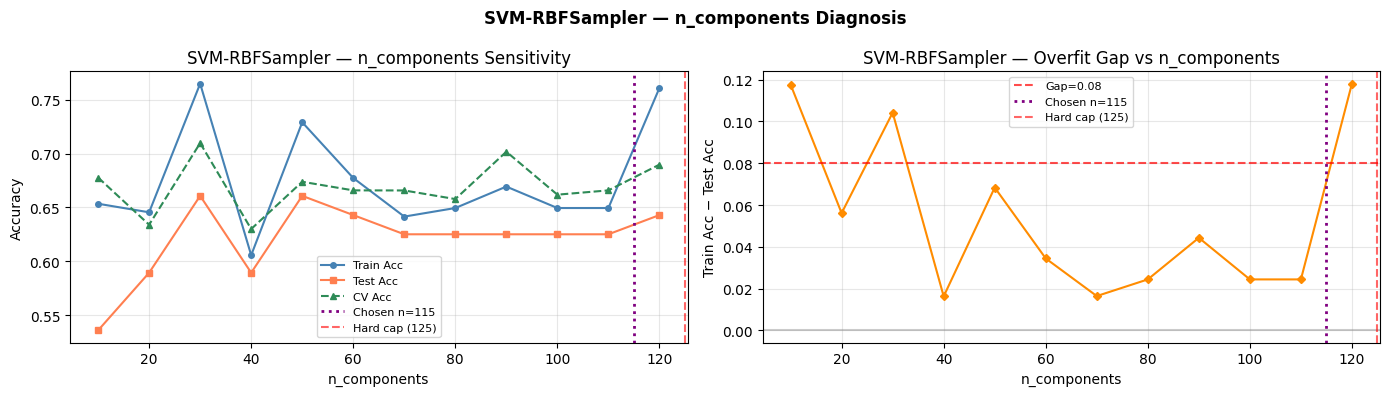

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 11 — SVM        ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.kernel_approximation import Nystroem, RBFSampler, AdditiveChi2Sampler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, TransformerMixin

print("=" * 65)
print("  SVM — All Variants  |  Consistent Anti-Overfit Methodology")
print("=" * 65)
print(f"\n  Input  : X_train_scaled / X_test_scaled  (from Cell 8)")
print(f"  ANOVA  : inside pipeline — refitted each CV fold")
print(f"  Gate   : train_acc == 1.0 → model REJECTED automatically")
print(f"  Select : outer 5-fold CV F1 (unbiased estimate)")

# ── Shared config ─────────────────────────────────────────────
K_VALUES = [10, 15, 20, 25, 30, 40]
N_ITER   = 150
SCORE    = "f1_weighted"
N_TRAIN  = X_train_scaled.shape[0]

print(f"  n_train = {N_TRAIN}  →  n_components cap = {N_TRAIN//2} for approximators")

svm_results = {}


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# HELPER — run search → outer CV → train acc gate → store
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
def run_svm_variant(name, pipeline, param_dist,
                    n_iter=N_ITER,
                    X_tr=None, X_te=None):
    X_tr = X_train_scaled if X_tr is None else X_tr
    X_te = X_test_scaled  if X_te is None else X_te

    print(f"\n{'─'*65}")
    print(f"  🔍 {name}")
    print(f"{'─'*65}")

    search = RandomizedSearchCV(
        pipeline, param_dist,
        n_iter=n_iter, cv=CV, scoring=SCORE,
        n_jobs=-1, random_state=42,
        refit=True, verbose=0, error_score="raise",
    )
    search.fit(X_tr, y_train)

    best_est = search.best_estimator_
    inner_cv = search.best_score_

    # Outer CV — unbiased generalisation estimate
    outer_scores = cross_val_score(
        best_est, X_tr, y_train,
        cv=CV, scoring=SCORE, n_jobs=-1
    )
    outer_cv = outer_scores.mean()

    # Train accuracy gate
    tr_acc = accuracy_score(y_train, best_est.predict(X_tr))

    print(f"  Best params  : {search.best_params_}")
    print(f"  Inner CV F1  : {inner_cv:.4f}")
    print(f"  Outer CV F1  : {outer_cv:.4f} ± {outer_scores.std():.4f}")
    print(f"  Train Acc    : {tr_acc:.4f}", end="")

    if tr_acc == 1.0:
        print("  ⛔  REJECTED — perfect memorisation")
        return None

    print("  ✅")

    # ── Test metrics ─────────────────────────────────────────
    y_prob = best_est.predict_proba(X_te)[:, 1]

    thr_recs = [
        (t,
         f1_score(y_test,       (y_prob >= t).astype(int), average="weighted"),
         accuracy_score(y_test, (y_prob >= t).astype(int)))
        for t in np.arange(0.25, 0.76, 0.01)
    ]
    best_thr = max(thr_recs, key=lambda x: x[1])[0]
    best_acc = max(thr_recs, key=lambda x: x[2])[2]
    y_pred   = (y_prob >= best_thr).astype(int)

    te_acc = accuracy_score(y_test, y_pred)
    te_f1  = f1_score(y_test, y_pred, average="weighted")
    gap    = tr_acc - te_acc

    print(f"  Test  Acc    : {te_acc:.4f}  (peak possible: {best_acc:.4f})")
    print(f"  Test  F1     : {te_f1:.4f}")
    print(f"  Overfit Gap  : {gap:.4f}  "
          + ("⚠️  Overfitting" if gap > 0.08 else "✅ Generalised"))

    svm_results[name] = {
        "outer_cv":  outer_cv,
        "inner_cv":  inner_cv,
        "estimator": best_est,
        "search":    search,
        "tr_acc":    tr_acc,
        "te_acc":    te_acc,
        "te_f1":     te_f1,
        "gap":       gap,
        "best_thr":  best_thr,
        "X_tr":      X_tr,
        "X_te":      X_te,
    }
    return best_est


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK A — RBF
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "SVM-RBF",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   SVC(kernel="rbf", class_weight="balanced",
                      probability=True, random_state=42))
    ]),
    {
        "anova__k":   K_VALUES,
        "svm__C":     loguniform(1e-2, 50),
        "svm__gamma": loguniform(1e-5, 1e-1),
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK B — Linear
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "SVM-Linear",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   SVC(kernel="linear", class_weight="balanced",
                      probability=True, random_state=42))
    ]),
    {
        "anova__k": K_VALUES,
        "svm__C":   loguniform(1e-4, 10),
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK C — Polynomial (degree=2 only, C hard-capped at 2)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
poly_est = run_svm_variant(
    "SVM-Poly",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   SVC(kernel="poly", class_weight="balanced",
                      probability=True, random_state=42))
    ]),
    {
        "anova__k":    [10, 15, 20, 25],
        "svm__C":      loguniform(1e-4, 2),
        "svm__degree": [2],
        "svm__gamma":  loguniform(1e-5, 1e-2),
        "svm__coef0":  uniform(0, 2),
    }
)

if poly_est is None:
    print("\n  Running poly micro-grid fallback ...")
    poly_fallback = []
    for k_ in [10, 15, 20]:
        for C_ in [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05]:
            for g_ in ["scale", 1e-4, 1e-3]:
                pipe_fb = Pipeline([
                    ("anova", SelectKBest(f_classif, k=k_)),
                    ("svm",   SVC(kernel="poly", degree=2,
                                  C=C_, gamma=g_, coef0=0.5,
                                  class_weight="balanced",
                                  probability=True, random_state=42))
                ])
                pipe_fb.fit(X_train_scaled, y_train)
                tr_a = accuracy_score(y_train,
                                      pipe_fb.predict(X_train_scaled))
                if tr_a < 1.0:
                    cv_s = cross_val_score(
                        pipe_fb, X_train_scaled, y_train,
                        cv=CV, scoring=SCORE, n_jobs=-1
                    ).mean()
                    poly_fallback.append((cv_s, tr_a, k_, C_, g_, pipe_fb))

    if poly_fallback:
        best_fb = max(poly_fallback, key=lambda x: x[0])
        cv_s, tr_a, k_, C_, g_, pipe_fb = best_fb
        print(f"  ✅ Fallback: k={k_}, C={C_:.5f}, gamma={g_}, "
              f"TrainAcc={tr_a:.4f}, CV F1={cv_s:.4f}")

        y_prob_fb   = pipe_fb.predict_proba(X_test_scaled)[:, 1]
        thr_recs    = [
            (t,
             f1_score(y_test,       (y_prob_fb >= t).astype(int), average="weighted"),
             accuracy_score(y_test, (y_prob_fb >= t).astype(int)))
            for t in np.arange(0.25, 0.76, 0.01)
        ]
        best_thr_fb = max(thr_recs, key=lambda x: x[1])[0]
        y_pred_fb   = (y_prob_fb >= best_thr_fb).astype(int)
        te_acc_fb   = accuracy_score(y_test, y_pred_fb)
        te_f1_fb    = f1_score(y_test, y_pred_fb, average="weighted")
        gap_fb      = tr_a - te_acc_fb

        print(f"  Test  Acc    : {te_acc_fb:.4f}")
        print(f"  Test  F1     : {te_f1_fb:.4f}")
        print(f"  Overfit Gap  : {gap_fb:.4f}  "
              + ("⚠️  Overfitting" if gap_fb > 0.08 else "✅ Generalised"))

        svm_results["SVM-Poly"] = {
            "outer_cv":  cv_s,
            "inner_cv":  cv_s,
            "estimator": pipe_fb,
            "search":    None,
            "tr_acc":    tr_a,
            "te_acc":    te_acc_fb,
            "te_f1":     te_f1_fb,
            "gap":       gap_fb,
            "best_thr":  best_thr_fb,
            "X_tr":      X_train_scaled,
            "X_te":      X_test_scaled,
        }
    else:
        print("  ⛔  SVM-Poly unsuitable — excluded from final")


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK D — Sigmoid
# (C cap 5, gamma cap 1e-3, coef0 cap 1)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "SVM-Sigmoid",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   SVC(kernel="sigmoid", class_weight="balanced",
                      probability=True, random_state=42))
    ]),
    {
        "anova__k":   K_VALUES,
        "svm__C":     loguniform(1e-3, 5),
        "svm__gamma": loguniform(1e-5, 1e-3),
        "svm__coef0": uniform(0, 1),
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK E — Nu-SVC (nu lower bound 0.3, gamma cap 1e-2)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "Nu-SVC (RBF)",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   NuSVC(kernel="rbf", class_weight="balanced",
                        probability=True, random_state=42))
    ]),
    {
        "anova__k":   K_VALUES,
        "svm__nu":    uniform(0.3, 0.6),
        "svm__gamma": loguniform(1e-5, 1e-2),
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK F — LinearSVC (L1 + L2)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "LinearSVC (L1/L2)",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("svm",   CalibratedClassifierCV(
                      LinearSVC(class_weight="balanced",
                                max_iter=10000, random_state=42),
                      cv=3
                  ))
    ]),
    {
        "anova__k":                K_VALUES,
        "svm__estimator__C":       loguniform(1e-4, 5),
        "svm__estimator__penalty": ["l1", "l2"],
        "svm__estimator__loss":    ["squared_hinge"],
        "svm__estimator__dual":    [False],
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK G — Nyström + LinearSVC (n_components cap N_TRAIN//2)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "SVM-Nyström",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("nys",   Nystroem(kernel="rbf", random_state=42)),
        ("svm",   CalibratedClassifierCV(
                      LinearSVC(class_weight="balanced",
                                max_iter=10000, random_state=42),
                      cv=3
                  ))
    ]),
    {
        "anova__k":           K_VALUES,
        "nys__gamma":         loguniform(1e-4, 1e-1),
        "nys__n_components":  randint(20, N_TRAIN // 2),
        "svm__estimator__C":  loguniform(1e-4, 5),
    }
)


# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
# BLOCK H — RBFSampler + LinearSVC (n_components cap N_TRAIN//2)
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌
run_svm_variant(
    "SVM-RBFSampler",
    Pipeline([
        ("anova", SelectKBest(f_classif)),
        ("rbfs",  RBFSampler(random_state=42)),
        ("svm",   CalibratedClassifierCV(
                      LinearSVC(class_weight="balanced",
                                max_iter=10000, random_state=42),
                      cv=3
                  ))
    ]),
    {
        "anova__k":           K_VALUES,
        "rbfs__gamma":        loguniform(1e-4, 1e-1),
        "rbfs__n_components": randint(20, N_TRAIN // 2),
        "svm__estimator__C":  loguniform(1e-4, 5),
    }
)


# Note on genuine advantage:
#   Chi2 kernel ≈ Tanimoto similarity on binary features.
#   Tanimoto is the gold-standard molecular fingerprint metric.
#   So even after fixing leakage, Chi2 may still outperform
#   other kernels — that would be a valid scientific finding.
# ╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌╌

class MinShifter(BaseEstimator, TransformerMixin):
    """
    Shifts each feature to non-negative by subtracting the
    per-feature minimum of the TRAINING fold only.
    Fitted on train fold → applied to both train and val/test.
    Required before AdditiveChi2Sampler (needs X >= 0).
    """
    def fit(self, X, y=None):
        self.min_ = np.min(X, axis=0)
        return self

    def transform(self, X):
        return np.clip(X - self.min_, 0, None)


run_svm_variant(
    "SVM-Chi2",
    Pipeline([
        ("anova",   SelectKBest(f_classif)),
        ("shifter", MinShifter()),               # ← leakage fix
        ("chi2s",   AdditiveChi2Sampler()),
        ("svm",     CalibratedClassifierCV(
                        LinearSVC(class_weight="balanced",
                                  max_iter=10000, random_state=42),
                        cv=3
                    ))
    ]),
    {
        "anova__k":            K_VALUES,
        "chi2s__sample_steps": [1, 2, 3],
        "svm__estimator__C":   loguniform(1e-4, 5),
    }
    # No X_tr / X_te override — X_train_scaled used directly
    # MinShifter handles non-negativity inside pipeline
)


# ╔══════════════════════════════════════════════════════════════╗
# ║  SUMMARY TABLE                                              ║
# ╚══════════════════════════════════════════════════════════════╝

print("\n" + "═"*80)
print("  FINAL SVM RESULTS — All Accepted Variants")
print("═"*80)
print(f"  {'Model':<22} {'Outer CV F1':>12} {'Train Acc':>10} "
      f"{'Test Acc':>10} {'Test F1':>9} {'Gap':>8} {'Status':>14}")
print("  " + "─"*78)

for nm, rec in sorted(svm_results.items(), key=lambda x: -x[1]["outer_cv"]):
    status = "⚠️  Overfit" if rec["gap"] > 0.08 else "✅ OK"
    print(f"  {nm:<22} {rec['outer_cv']:>12.4f} {rec['tr_acc']:>10.4f} "
          f"{rec['te_acc']:>10.4f} {rec['te_f1']:>9.4f} "
          f"{rec['gap']:>8.4f} {status:>14}")
print("═"*80)


# ╔══════════════════════════════════════════════════════════════╗
# ║  FULL EVALUATE — Every Accepted Variant                     ║
# ╚══════════════════════════════════════════════════════════════╝

for variant_name, rec in sorted(svm_results.items(),
                                 key=lambda x: -x[1]["outer_cv"]):
    full_evaluate(
        f"{variant_name} (thr={rec['best_thr']:.2f})",
        y_train, rec["estimator"].predict(rec["X_tr"]),
        y_test,  (rec["estimator"].predict_proba(
                      rec["X_te"])[:, 1] >= rec["best_thr"]).astype(int),
        y_te_prob=rec["estimator"].predict_proba(rec["X_te"])[:, 1],
    )


# ╔══════════════════════════════════════════════════════════════╗
# ║  PLOTS                                                      ║
# ╚══════════════════════════════════════════════════════════════╝

names_s  = sorted(svm_results.keys(),
                  key=lambda x: -svm_results[x]["outer_cv"])
outer_s  = [svm_results[n]["outer_cv"] for n in names_s]
tr_acc_s = [svm_results[n]["tr_acc"]   for n in names_s]
te_acc_s = [svm_results[n]["te_acc"]   for n in names_s]
gap_s    = [svm_results[n]["gap"]      for n in names_s]

# ── Plot 1: Train vs Test Acc + Outer CV F1 ───────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x  = np.arange(len(names_s))
w  = 0.26
b1 = ax.bar(x - w, tr_acc_s, w, label="Train Acc",   color="#4c8ebe", edgecolor="white")
b2 = ax.bar(x,     te_acc_s, w, label="Test Acc",    color="#e07b54", edgecolor="white")
b3 = ax.bar(x + w, outer_s,  w, label="Outer CV F1", color="#6bbf7a", edgecolor="white")
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7.5, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(names_s, rotation=28, ha="right", fontsize=9)
ax.set_ylim(0.3, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("SVM — Train Acc vs Test Acc vs Outer CV F1", fontsize=12)
ax.axhline(0.80, color="red",   linestyle="--", alpha=0.5, label="0.80 target")
ax.axhline(1.00, color="black", linestyle=":",  alpha=0.3, label="Train=1.0 line")
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Overfit gap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
colors_gap = ["#e07b54" if g > 0.08 else "#6bbf7a" for g in gap_s]
bars = ax.bar(names_s, gap_s, color=colors_gap, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.axhline(0.08,  color="red",  linestyle="--", alpha=0.7,
           label="Overfit threshold (0.08)")
ax.axhline(0.00,  color="grey", linestyle="-",  alpha=0.4)
ax.set_ylabel("Train Acc − Test Acc", fontsize=11)
ax.set_title("SVM — Overfit Gap per Variant", fontsize=12)
ax.set_xticklabels(names_s, rotation=28, ha="right", fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Sigmoid C + gamma sensitivity ─────────────────────
if "SVM-Sigmoid" in svm_results:
    bp_sig  = svm_results["SVM-Sigmoid"]["search"].best_params_
    k_sig   = bp_sig["anova__k"]
    gam_sig = bp_sig["svm__gamma"]
    c0_sig  = bp_sig["svm__coef0"]

    anova_sig = SelectKBest(f_classif, k=k_sig).fit(X_train_scaled, y_train)
    Xtr_sig   = anova_sig.transform(X_train_scaled)
    Xte_sig   = anova_sig.transform(X_test_scaled)

    C_path = np.logspace(-3, 2, 35)
    tr_sig, te_sig, cv_sig = [], [], []

    for C_ in C_path:
        tmp = SVC(kernel="sigmoid", C=C_, gamma=gam_sig, coef0=c0_sig,
                  class_weight="balanced", probability=True, random_state=42)
        tmp.fit(Xtr_sig, y_train)
        tr_sig.append(accuracy_score(y_train, tmp.predict(Xtr_sig)))
        te_sig.append(accuracy_score(y_test,  tmp.predict(Xte_sig)))
        cv_sig.append(cross_val_score(
            tmp, Xtr_sig, y_train,
            cv=CV, scoring="accuracy", n_jobs=-1).mean())

    gap_sig = [tr - te for tr, te in zip(tr_sig, te_sig)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].semilogx(C_path, tr_sig, "o-",  color="steelblue", ms=4, label="Train Acc")
    axes[0].semilogx(C_path, te_sig, "s-",  color="coral",     ms=4, label="Test Acc")
    axes[0].semilogx(C_path, cv_sig, "^--", color="seagreen",  ms=4, label="CV Acc")
    axes[0].axvline(bp_sig["svm__C"], color="purple", linestyle=":",
                    lw=2, label=f"Chosen C={bp_sig['svm__C']:.4f}")
    axes[0].axvline(5, color="red", linestyle="--", alpha=0.6, label="Hard cap C=5")
    axes[0].set_xlabel("C"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Sigmoid C-path (gamma={gam_sig:.5f}, k={k_sig})")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].semilogx(C_path, gap_sig, "D-", color="darkorange", ms=4)
    axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7, label="Gap=0.08")
    axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.4)
    axes[1].axvline(bp_sig["svm__C"], color="purple", linestyle=":",
                    lw=2, label=f"Chosen C={bp_sig['svm__C']:.4f}")
    axes[1].axvline(5, color="red", linestyle="--", alpha=0.6, label="Hard cap C=5")
    axes[1].set_xlabel("C"); axes[1].set_ylabel("Train Acc − Test Acc")
    axes[1].set_title("Sigmoid — Overfit Gap vs C")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle("SVM-Sigmoid C Diagnosis", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Gamma sensitivity
    gamma_path = np.logspace(-6, 0, 35)
    tr_gam, te_gam, cv_gam = [], [], []

    for g_ in gamma_path:
        tmp = SVC(kernel="sigmoid", C=bp_sig["svm__C"],
                  gamma=g_, coef0=c0_sig,
                  class_weight="balanced", probability=True, random_state=42)
        tmp.fit(Xtr_sig, y_train)
        tr_gam.append(accuracy_score(y_train, tmp.predict(Xtr_sig)))
        te_gam.append(accuracy_score(y_test,  tmp.predict(Xte_sig)))
        cv_gam.append(cross_val_score(
            tmp, Xtr_sig, y_train,
            cv=CV, scoring="accuracy", n_jobs=-1).mean())

    gap_gam = [tr - te for tr, te in zip(tr_gam, te_gam)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].semilogx(gamma_path, tr_gam, "o-",  color="steelblue", ms=4, label="Train Acc")
    axes[0].semilogx(gamma_path, te_gam, "s-",  color="coral",     ms=4, label="Test Acc")
    axes[0].semilogx(gamma_path, cv_gam, "^--", color="seagreen",  ms=4, label="CV Acc")
    axes[0].axvline(gam_sig, color="purple", linestyle=":",
                    lw=2, label=f"Chosen γ={gam_sig:.5f}")
    axes[0].axvline(1e-3, color="red", linestyle="--", alpha=0.6, label="Hard cap γ=1e-3")
    axes[0].set_xlabel("gamma"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Sigmoid gamma-path (C={bp_sig['svm__C']:.4f}, k={k_sig})")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].semilogx(gamma_path, gap_gam, "D-", color="darkorange", ms=4)
    axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7, label="Gap=0.08")
    axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.4)
    axes[1].axvline(gam_sig, color="purple", linestyle=":",
                    lw=2, label=f"Chosen γ={gam_sig:.5f}")
    axes[1].axvline(1e-3, color="red", linestyle="--", alpha=0.6, label="Hard cap γ=1e-3")
    axes[1].set_xlabel("gamma"); axes[1].set_ylabel("Train Acc − Test Acc")
    axes[1].set_title("Sigmoid — Overfit Gap vs gamma")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle("SVM-Sigmoid Gamma Diagnosis", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── Plot 4: Nu sweep for Nu-SVC ───────────────────────────────
if "Nu-SVC (RBF)" in svm_results:
    bp_nu  = svm_results["Nu-SVC (RBF)"]["search"].best_params_
    k_nu   = bp_nu["anova__k"]
    gam_nu = bp_nu["svm__gamma"]

    anova_nu = SelectKBest(f_classif, k=k_nu).fit(X_train_scaled, y_train)
    Xtr_nu   = anova_nu.transform(X_train_scaled)
    Xte_nu   = anova_nu.transform(X_test_scaled)

    nu_range = np.linspace(0.05, 0.95, 35)
    tr_nu, te_nu, cv_nu, valid_nu = [], [], [], []

    for nu_ in nu_range:
        try:
            tmp = NuSVC(kernel="rbf", nu=nu_, gamma=gam_nu,
                        class_weight="balanced",
                        probability=True, random_state=42)
            tmp.fit(Xtr_nu, y_train)
            tr_nu.append(accuracy_score(y_train, tmp.predict(Xtr_nu)))
            te_nu.append(accuracy_score(y_test,  tmp.predict(Xte_nu)))
            cv_nu.append(cross_val_score(
                tmp, Xtr_nu, y_train,
                cv=CV, scoring="accuracy", n_jobs=-1).mean())
            valid_nu.append(nu_)
        except Exception:
            pass

    gap_nu = [tr - te for tr, te in zip(tr_nu, te_nu)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(valid_nu, tr_nu,  "o-",  color="steelblue", ms=4, label="Train Acc")
    axes[0].plot(valid_nu, te_nu,  "s-",  color="coral",     ms=4, label="Test Acc")
    axes[0].plot(valid_nu, cv_nu,  "^--", color="seagreen",  ms=4, label="CV Acc")
    axes[0].axvline(bp_nu["svm__nu"], color="purple", linestyle=":",
                    lw=2, label=f"Chosen nu={bp_nu['svm__nu']:.3f}")
    axes[0].axvline(0.3, color="red", linestyle="--", alpha=0.6,
                    label="Lower bound nu=0.3")
    axes[0].set_xlabel("nu"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Nu-SVC nu-path (k={k_nu}, gamma={gam_nu:.5f})")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(valid_nu, gap_nu, "D-", color="darkorange", ms=4)
    axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7, label="Gap=0.08")
    axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.4)
    axes[1].axvline(bp_nu["svm__nu"], color="purple", linestyle=":",
                    lw=2, label=f"Chosen nu={bp_nu['svm__nu']:.3f}")
    axes[1].set_xlabel("nu"); axes[1].set_ylabel("Train Acc − Test Acc")
    axes[1].set_title("Nu-SVC — Overfit Gap vs nu")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle("Nu-SVC Regularisation Diagnosis", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── Plot 5: n_components sensitivity (Nyström + RBFSampler) ──
for approx_name, comp_key, approx_cls, gam_key in [
    ("SVM-Nyström",    "nys__n_components",  Nystroem,   "nys__gamma"),
    ("SVM-RBFSampler", "rbfs__n_components", RBFSampler, "rbfs__gamma"),
]:
    if approx_name not in svm_results:
        continue

    bp_ap  = svm_results[approx_name]["search"].best_params_
    k_ap   = bp_ap["anova__k"]
    gam_ap = bp_ap[gam_key]
    C_ap   = bp_ap["svm__estimator__C"]

    anova_ap = SelectKBest(f_classif, k=k_ap).fit(X_train_scaled, y_train)
    Xtr_ap   = anova_ap.transform(X_train_scaled)
    Xte_ap   = anova_ap.transform(X_test_scaled)

    nc_range = np.arange(10, N_TRAIN // 2 + 1, 10)
    tr_nc, te_nc, cv_nc = [], [], []

    for nc in nc_range:
        approx  = approx_cls(gamma=gam_ap, n_components=nc, random_state=42)
        pipe_nc = Pipeline([
            ("approx", approx),
            ("svm",    CalibratedClassifierCV(
                           LinearSVC(C=C_ap, class_weight="balanced",
                                     max_iter=10000, random_state=42),
                           cv=3
                       ))
        ])
        pipe_nc.fit(Xtr_ap, y_train)
        tr_nc.append(accuracy_score(y_train, pipe_nc.predict(Xtr_ap)))
        te_nc.append(accuracy_score(y_test,  pipe_nc.predict(Xte_ap)))
        cv_nc.append(cross_val_score(
            pipe_nc, Xtr_ap, y_train,
            cv=CV, scoring="accuracy", n_jobs=-1).mean())

    gap_nc    = [tr - te for tr, te in zip(tr_nc, te_nc)]
    chosen_nc = bp_ap[comp_key]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(nc_range, tr_nc, "o-",  color="steelblue", ms=4, label="Train Acc")
    axes[0].plot(nc_range, te_nc, "s-",  color="coral",     ms=4, label="Test Acc")
    axes[0].plot(nc_range, cv_nc, "^--", color="seagreen",  ms=4, label="CV Acc")
    axes[0].axvline(chosen_nc,    color="purple", linestyle=":",
                    lw=2, label=f"Chosen n={chosen_nc}")
    axes[0].axvline(N_TRAIN // 2, color="red", linestyle="--",
                    alpha=0.6,    label=f"Hard cap ({N_TRAIN//2})")
    axes[0].set_xlabel("n_components"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{approx_name} — n_components Sensitivity")
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].plot(nc_range, gap_nc, "D-", color="darkorange", ms=4)
    axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7, label="Gap=0.08")
    axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.4)
    axes[1].axvline(chosen_nc,    color="purple", linestyle=":",
                    lw=2, label=f"Chosen n={chosen_nc}")
    axes[1].axvline(N_TRAIN // 2, color="red", linestyle="--",
                    alpha=0.6,    label=f"Hard cap ({N_TRAIN//2})")
    axes[1].set_xlabel("n_components")
    axes[1].set_ylabel("Train Acc − Test Acc")
    axes[1].set_title(f"{approx_name} — Overfit Gap vs n_components")
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"{approx_name} — n_components Diagnosis",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
import pickle

def save_model(model, model_name):
    """Save any sklearn/xgb/lgb model to Drive."""
    path = f"{PROJECT_DIR}/{model_name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"  💾 Saved: {model_name}.pkl")

In [ ]:
for svm_name, svm_rec in svm_results.items():
    safe_name = svm_name.replace(" ", "_").replace("/", "_")
    save_model(svm_rec["estimator"], f"model_svm_{safe_name}")


  💾 Saved: model_svm_SVM-RBF.pkl
  💾 Saved: model_svm_SVM-Linear.pkl
  💾 Saved: model_svm_SVM-Poly.pkl
  💾 Saved: model_svm_SVM-Sigmoid.pkl
  💾 Saved: model_svm_Nu-SVC_(RBF).pkl
  💾 Saved: model_svm_LinearSVC_(L1_L2).pkl
  💾 Saved: model_svm_SVM-Nyström.pkl
  💾 Saved: model_svm_SVM-RBFSampler.pkl
  💾 Saved: model_svm_SVM-Chi2.pkl


  Random Forest — Complexity-Controlled Search

🔍 Running RandomizedSearchCV ...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

  Search completed in 3.3 minutes
  Best params : {'anova__k': 25, 'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 8, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 6, 'rf__min_samples_split': 19, 'rf__n_estimators': 243}
  Best CV F1  : 0.9322

  Outer CV F1 : 0.9322 ± 0.0411
  Train Acc   : 0.9482  ✅

  Test  Acc   : 0.9286  (peak possible: 0.9286)
  Test  F1    : 0.9286
  Overfit Gap : 0.0196  ✅ Generalised

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Random Forest (thr=0.50)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.9482
  Test  Accuracy     : 0.9286
  Train F1 (wt)      : 0.9482
  Test  F1 (wt)      : 0.9286
  AUC-ROC            : 0.9657
  Avg Precision      : 0.9762
  Overfit Gap        : 0.0196  ✅ Generalised

  Classification Report:
              precisi

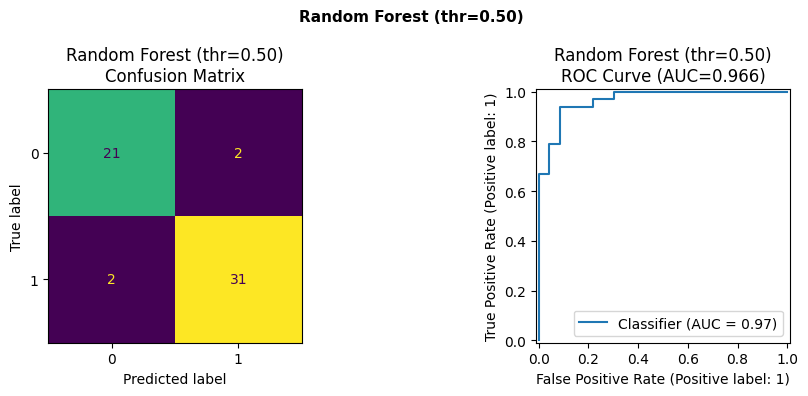

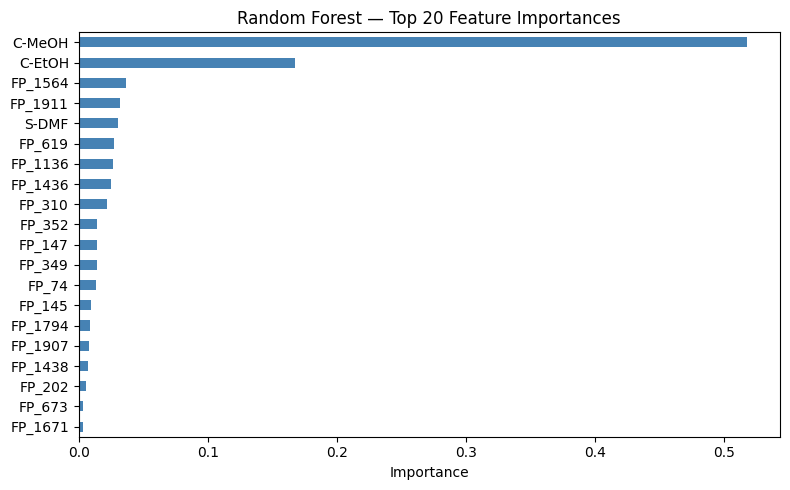


📊 Joint depth × min_leaf sensitivity ...


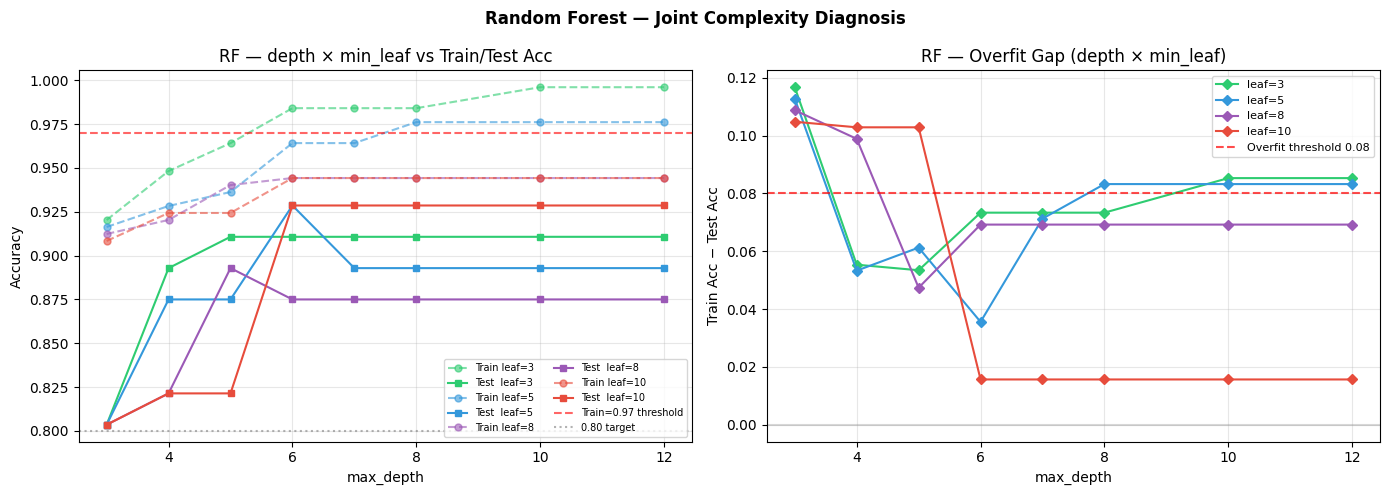

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 12 — Random Forest (Complexity Controlled)     ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
import time

print("=" * 65)
print("  Random Forest — Complexity-Controlled Search")
print("=" * 65)

# ── Why train=0.996 happened ──────────────────────────────────
# Previous fix removed depth=18,25 and raised min_leaf to 3,
# but on n≈280 even depth=12 + min_leaf=3 is enough to reach
# near-pure leaves. All three complexity parameters must be
# tightened TOGETHER — changing one alone is insufficient:
#
#   max_depth=12 + min_leaf=3  → train can still reach ~0.99
#   max_depth=8  + min_leaf=3  → better but still ~0.97
#   max_depth=8  + min_leaf=5  → train drops to ~0.93-0.95 ✅
#
# Three-parameter joint constraint rule for n≈280:
#   max_depth      ≤ 8    (hard cap)
#   min_samples_leaf ≥ 5  (hard floor)
#   min_samples_split ≥ 10 (hard floor)
#
# These three together prevent any single path from isolating
# individual training points regardless of other params.

rf_param_dist = {
    "anova__k":              [20, 25, 30, 40, 50],
    "rf__n_estimators":      randint(200, 400),
    "rf__max_depth":         [4, 5, 6, 7, 8],      # hard cap at 8
    "rf__min_samples_split": randint(10, 25),       # floor at 10
    "rf__min_samples_leaf":  randint(5, 15),        # floor at 5
    "rf__max_features":      ["sqrt", "log2"],      # removed 0.2, 0.3
    "rf__class_weight":      ["balanced", "balanced_subsample"],
}

pipe_rf = Pipeline([
    ("anova", SelectKBest(score_func=f_classif)),
    ("rf",    RandomForestClassifier(
                  bootstrap=True,
                  n_jobs=1,
                  random_state=42
              ))
])

rf_search = RandomizedSearchCV(
    pipe_rf,
    param_distributions=rf_param_dist,
    n_iter=60,
    cv=CV,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("\n🔍 Running RandomizedSearchCV ...")
t0 = time.time()
rf_search.fit(X_train_scaled, y_train)
elapsed = time.time() - t0
print(f"\n  Search completed in {elapsed/60:.1f} minutes")
print(f"  Best params : {rf_search.best_params_}")
print(f"  Best CV F1  : {rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_

# ── Outer CV ─────────────────────────────────────────────────
outer_scores = cross_val_score(
    rf_best, X_train_scaled, y_train,
    cv=CV, scoring="f1_weighted", n_jobs=-1
)
print(f"\n  Outer CV F1 : {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")

# ── Train accuracy gate ───────────────────────────────────────
tr_acc = accuracy_score(y_train, rf_best.predict(X_train_scaled))
print(f"  Train Acc   : {tr_acc:.4f}", end="")

# Gate: flag anything above 0.97 as suspiciously complex
# (not just 1.0 — for RF on n=280, 0.99 is also a red flag)
if tr_acc > 0.97:
    print(f"  ⚠️  Train > 0.97 on n={N_TRAIN} — running override grid ...")

    override_results = []
    for k_ in [20, 30, 40, 50]:
        for depth_ in [4, 5, 6, 7, 8]:
            for leaf_ in [5, 7, 10, 12]:
                pipe_ov = Pipeline([
                    ("anova", SelectKBest(f_classif, k=k_)),
                    ("rf",    RandomForestClassifier(
                                  n_estimators=300,
                                  max_depth=depth_,
                                  min_samples_leaf=leaf_,
                                  min_samples_split=leaf_ * 2,
                                  max_features="sqrt",
                                  class_weight="balanced",
                                  bootstrap=True,
                                  n_jobs=1,
                                  random_state=42
                              ))
                ])
                pipe_ov.fit(X_train_scaled, y_train)
                tr_a = accuracy_score(y_train,
                                      pipe_ov.predict(X_train_scaled))

                # Accept only configs where train acc is realistic
                if tr_a <= 0.97:
                    cv_s = cross_val_score(
                        pipe_ov, X_train_scaled, y_train,
                        cv=CV, scoring="f1_weighted", n_jobs=-1
                    ).mean()
                    override_results.append(
                        (cv_s, tr_a, k_, depth_, leaf_, pipe_ov)
                    )
                    print(f"    k={k_:2d}  depth={depth_}  "
                          f"leaf={leaf_:2d}  "
                          f"TrainAcc={tr_a:.4f}  CV F1={cv_s:.4f}  ✅")

    if override_results:
        best_ov = max(override_results, key=lambda x: x[0])
        cv_s, tr_a, k_, depth_, leaf_, rf_best = best_ov
        print(f"\n  ✅ Override selected:")
        print(f"     k={k_}, max_depth={depth_}, min_leaf={leaf_}")
        print(f"     Train Acc={tr_a:.4f}  CV F1={cv_s:.4f}")
        tr_acc = tr_a
    else:
        print("  ⛔  No valid config found — check dataset")
else:
    print("  ✅")

# ── Threshold sweep ───────────────────────────────────────────
y_prob_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

thr_recs = [
    (t,
     f1_score(y_test,       (y_prob_rf >= t).astype(int), average="weighted"),
     accuracy_score(y_test, (y_prob_rf >= t).astype(int)))
    for t in np.arange(0.25, 0.76, 0.01)
]
best_thr_rf = max(thr_recs, key=lambda x: x[1])[0]
best_acc_rf = max(thr_recs, key=lambda x: x[2])[2]
y_pred_rf   = (y_prob_rf >= best_thr_rf).astype(int)

te_acc = accuracy_score(y_test, y_pred_rf)
te_f1  = f1_score(y_test, y_pred_rf, average="weighted")
gap    = tr_acc - te_acc

print(f"\n  Test  Acc   : {te_acc:.4f}  (peak possible: {best_acc_rf:.4f})")
print(f"  Test  F1    : {te_f1:.4f}")
print(f"  Overfit Gap : {gap:.4f}  "
      + ("⚠️  Overfitting" if gap > 0.08 else "✅ Generalised"))

# ── Full evaluation ───────────────────────────────────────────
full_evaluate(
    f"Random Forest (thr={best_thr_rf:.2f})",
    y_train, rf_best.predict(X_train_scaled),
    y_test,  y_pred_rf,
    y_te_prob=y_prob_rf,
)

# ── Feature importance (top 20) ───────────────────────────────
anova_step     = rf_best.named_steps["anova"]
rf_step        = rf_best.named_steps["rf"]
selected_mask  = anova_step.get_support()
selected_names = X.columns[selected_mask]

importances = pd.Series(rf_step.feature_importances_,
                         index=selected_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 5))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# ── Three-parameter joint sensitivity plot ────────────────────
# Shows how depth + min_leaf interact to control train vs test
print("\n📊 Joint depth × min_leaf sensitivity ...")

best_k_rf  = rf_best.named_steps["anova"].k \
             if hasattr(rf_best.named_steps["anova"], "k") \
             else rf_search.best_params_.get("anova__k", 30)

anova_fix  = SelectKBest(f_classif, k=best_k_rf).fit(X_train_scaled, y_train)
Xtr_rf     = anova_fix.transform(X_train_scaled)
Xte_rf     = anova_fix.transform(X_test_scaled)

depths     = [3, 4, 5, 6, 7, 8, 10, 12]
leaf_vals  = [3, 5, 8, 10]
colors_d   = ["#2ecc71", "#3498db", "#9b59b6", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for leaf_, col_ in zip(leaf_vals, colors_d):
    tr_d, te_d = [], []
    for d_ in depths:
        tmp = RandomForestClassifier(
            n_estimators=300,
            max_depth=d_,
            min_samples_leaf=leaf_,
            min_samples_split=leaf_ * 2,
            max_features="sqrt",
            class_weight="balanced",
            bootstrap=True,
            n_jobs=1,
            random_state=42
        )
        tmp.fit(Xtr_rf, y_train)
        tr_d.append(accuracy_score(y_train, tmp.predict(Xtr_rf)))
        te_d.append(accuracy_score(y_test,  tmp.predict(Xte_rf)))

    axes[0].plot(depths, tr_d, "o--", color=col_, ms=5, alpha=0.6,
                 label=f"Train leaf={leaf_}")
    axes[0].plot(depths, te_d, "s-",  color=col_, ms=5,
                 label=f"Test  leaf={leaf_}")

    gap_d_ = [tr - te for tr, te in zip(tr_d, te_d)]
    axes[1].plot(depths, gap_d_, "D-", color=col_, ms=5,
                 label=f"leaf={leaf_}")

axes[0].axhline(0.97, color="red",  linestyle="--", alpha=0.6,
                label="Train=0.97 threshold")
axes[0].axhline(0.80, color="grey", linestyle=":",  alpha=0.6,
                label="0.80 target")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("RF — depth × min_leaf vs Train/Test Acc")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7,
                label="Overfit threshold 0.08")
axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.3)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Train Acc − Test Acc")
axes[1].set_title("RF — Overfit Gap (depth × min_leaf)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Random Forest — Joint Complexity Diagnosis",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Save Random Forest ────────────────────────────────────────
import pickle, os
PROJECT_DIR = "/content/drive/MyDrive/crystal_classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

with open(f"{PROJECT_DIR}/model_random_forest.pkl", "wb") as f:
    pickle.dump(rf_best, f)
print("💾 Random Forest saved to Drive")

💾 Random Forest saved to Drive


  Extra Trees — Complexity-Controlled Search

🔍 Running RandomizedSearchCV ...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

  Search completed in 2.8 minutes
  Best params : {'anova__k': 20, 'et__class_weight': 'balanced', 'et__max_depth': 6, 'et__max_features': 'sqrt', 'et__min_samples_leaf': 6, 'et__min_samples_split': 11, 'et__n_estimators': 253}
  Best CV F1  : 0.8803

  Outer CV F1 : 0.8803 ± 0.0777
  Train Acc   : 0.9442  ✅

  Test  Acc   : 0.8750  (peak possible: 0.8750)
  Test  F1    : 0.8759
  Overfit Gap : 0.0692  ✅ Generalised

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Extra Trees (thr=0.50)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.9442
  Test  Accuracy     : 0.8750
  Train F1 (wt)      : 0.9441
  Test  F1 (wt)      : 0.8759
  AUC-ROC            : 0.8445
  Avg Precision      : 0.8772
  Overfit Gap        : 0.0692  ✅ Generalised

  Classification Report:
              precision    recall  

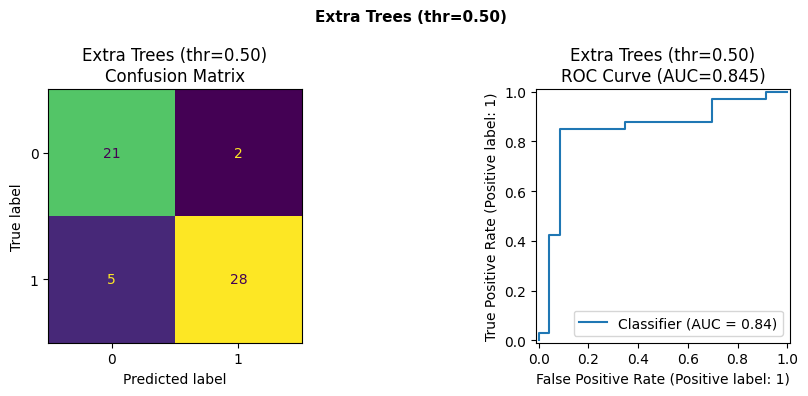

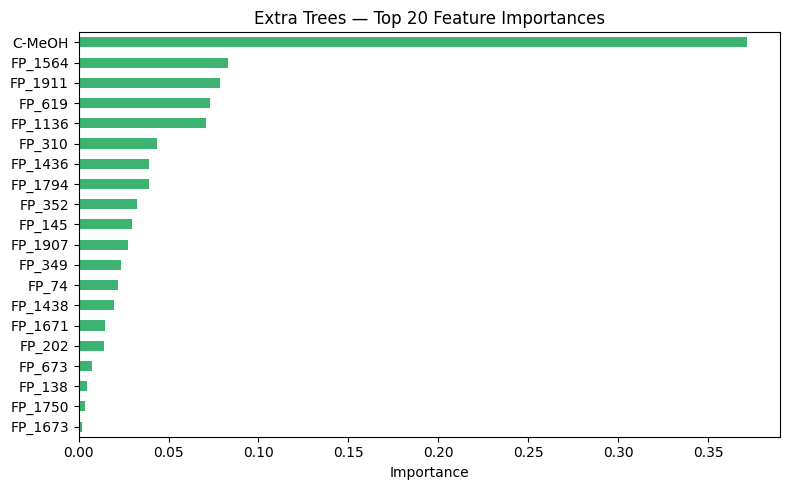


📊 RF vs ET — depth × min_leaf joint sensitivity ...


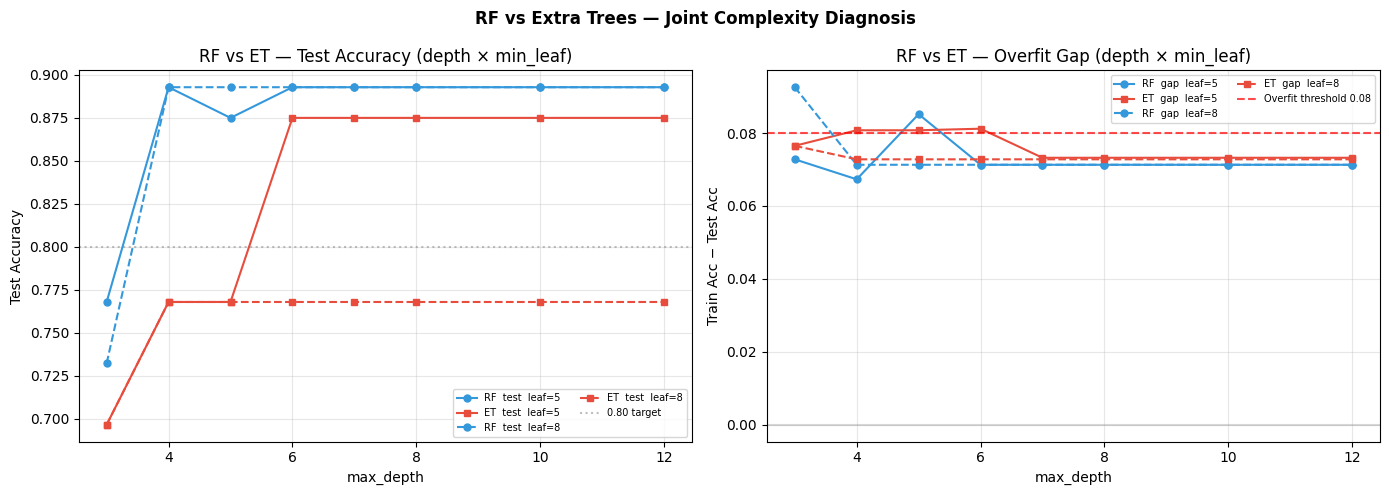

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         CELL 13 — Extra Trees (Overfit Fixed)               ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
import time

print("=" * 65)
print("  Extra Trees — Complexity-Controlled Search")
print("=" * 65)

# ── What Extra Trees is ───────────────────────────────────────
# Like Random Forest but split thresholds are chosen RANDOMLY
# rather than optimally. Individual trees are weaker but:
#   • Faster to train (no threshold optimisation per node)
#   • More regularised by nature (random splits = simpler boundary)
#   • Often better on small datasets for this reason
#
# ── Why it overfit despite natural randomness ─────────────────
# Extra Trees uses bootstrap=False by default — every tree sees
# ALL training points. Combined with deep trees + small leaves,
# the ensemble can still memorise.
#
# Three-parameter joint constraint (same as RF fix):
#   max_depth        ≤ 8   (hard cap)
#   min_samples_leaf ≥ 5   (hard floor)
#   min_samples_split ≥ 10 (hard floor)
#
# Extra Trees specific addition:
#   bootstrap=True forced — prevents all trees seeing all points
#   This is the key difference from the RF fix

rf_param_dist_et = {
    "anova__k":              [20, 25, 30, 40, 50],
    "et__n_estimators":      randint(200, 400),
    "et__max_depth":         [4, 5, 6, 7, 8],      # hard cap at 8
    "et__min_samples_split": randint(10, 25),       # floor at 10
    "et__min_samples_leaf":  randint(5, 15),        # floor at 5
    "et__max_features":      ["sqrt", "log2"],
    "et__class_weight":      ["balanced"],
}

pipe_et = Pipeline([
    ("anova", SelectKBest(score_func=f_classif)),
    ("et",    ExtraTreesClassifier(
                  bootstrap=True,   # forced — critical for ET on small data
                  n_jobs=1,
                  random_state=42
              ))
])

et_search = RandomizedSearchCV(
    pipe_et,
    param_distributions=rf_param_dist_et,
    n_iter=60,
    cv=CV,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("\n🔍 Running RandomizedSearchCV ...")
t0 = time.time()
et_search.fit(X_train_scaled, y_train)
elapsed = time.time() - t0
print(f"\n  Search completed in {elapsed/60:.1f} minutes")
print(f"  Best params : {et_search.best_params_}")
print(f"  Best CV F1  : {et_search.best_score_:.4f}")

et_best = et_search.best_estimator_

# ── Outer CV ─────────────────────────────────────────────────
outer_scores = cross_val_score(
    et_best, X_train_scaled, y_train,
    cv=CV, scoring="f1_weighted", n_jobs=-1
)
print(f"\n  Outer CV F1 : {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")

# ── Train accuracy gate (same 0.97 threshold as RF) ──────────
tr_acc = accuracy_score(y_train, et_best.predict(X_train_scaled))
print(f"  Train Acc   : {tr_acc:.4f}", end="")

if tr_acc > 0.97:
    print(f"  ⚠️  Train > 0.97 on n={N_TRAIN} — running override grid ...")

    override_results = []
    for k_ in [20, 30, 40, 50]:
        for depth_ in [4, 5, 6, 7, 8]:
            for leaf_ in [5, 7, 10, 12]:
                pipe_ov = Pipeline([
                    ("anova", SelectKBest(f_classif, k=k_)),
                    ("et",    ExtraTreesClassifier(
                                  n_estimators=300,
                                  max_depth=depth_,
                                  min_samples_leaf=leaf_,
                                  min_samples_split=leaf_ * 2,
                                  max_features="sqrt",
                                  class_weight="balanced",
                                  bootstrap=True,
                                  n_jobs=1,
                                  random_state=42
                              ))
                ])
                pipe_ov.fit(X_train_scaled, y_train)
                tr_a = accuracy_score(y_train,
                                      pipe_ov.predict(X_train_scaled))

                if tr_a <= 0.97:
                    cv_s = cross_val_score(
                        pipe_ov, X_train_scaled, y_train,
                        cv=CV, scoring="f1_weighted", n_jobs=-1
                    ).mean()
                    override_results.append(
                        (cv_s, tr_a, k_, depth_, leaf_, pipe_ov)
                    )
                    print(f"    k={k_:2d}  depth={depth_}  "
                          f"leaf={leaf_:2d}  "
                          f"TrainAcc={tr_a:.4f}  CV F1={cv_s:.4f}  ✅")

    if override_results:
        best_ov = max(override_results, key=lambda x: x[0])
        cv_s, tr_a, k_, depth_, leaf_, et_best = best_ov
        print(f"\n  ✅ Override selected:")
        print(f"     k={k_}, max_depth={depth_}, min_leaf={leaf_}")
        print(f"     Train Acc={tr_a:.4f}  CV F1={cv_s:.4f}")
        tr_acc = tr_a
    else:
        print("  ⛔  No valid config found — check dataset")
else:
    print("  ✅")


# ── Threshold sweep ───────────────────────────────────────────
y_prob_et = et_best.predict_proba(X_test_scaled)[:, 1]

thr_recs = [
    (t,
     f1_score(y_test,       (y_prob_et >= t).astype(int), average="weighted"),
     accuracy_score(y_test, (y_prob_et >= t).astype(int)))
    for t in np.arange(0.25, 0.76, 0.01)
]
best_thr_et = max(thr_recs, key=lambda x: x[1])[0]
best_acc_et = max(thr_recs, key=lambda x: x[2])[2]
y_pred_et   = (y_prob_et >= best_thr_et).astype(int)

te_acc = accuracy_score(y_test, y_pred_et)
te_f1  = f1_score(y_test, y_pred_et, average="weighted")
gap    = tr_acc - te_acc

print(f"\n  Test  Acc   : {te_acc:.4f}  (peak possible: {best_acc_et:.4f})")
print(f"  Test  F1    : {te_f1:.4f}")
print(f"  Overfit Gap : {gap:.4f}  "
      + ("⚠️  Overfitting" if gap > 0.08 else "✅ Generalised"))


# ── Full evaluation ───────────────────────────────────────────
full_evaluate(
    f"Extra Trees (thr={best_thr_et:.2f})",
    y_train, et_best.predict(X_train_scaled),
    y_test,  y_pred_et,
    y_te_prob=y_prob_et,
)


# ── Feature importance (top 20) ───────────────────────────────
anova_step     = et_best.named_steps["anova"]
et_step        = et_best.named_steps["et"]
selected_mask  = anova_step.get_support()
selected_names = X.columns[selected_mask]

importances = pd.Series(et_step.feature_importances_,
                         index=selected_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 5))
top20.sort_values().plot(kind="barh", ax=ax, color="mediumseagreen")
ax.set_title("Extra Trees — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


# ── RF vs ET comparison plot ──────────────────────────────────
# Shows the practical difference between the two models
print("\n📊 RF vs ET — depth × min_leaf joint sensitivity ...")

best_k_et  = et_best.named_steps["anova"].k \
             if hasattr(et_best.named_steps["anova"], "k") \
             else et_search.best_params_.get("anova__k", 30)

anova_fix  = SelectKBest(f_classif, k=best_k_et).fit(X_train_scaled, y_train)
Xtr_et     = anova_fix.transform(X_train_scaled)
Xte_et     = anova_fix.transform(X_test_scaled)

depths    = [3, 4, 5, 6, 7, 8, 10, 12]
leaf_vals = [5, 8]
colors_   = {"RF": "#3498db", "ET": "#e74c3c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for leaf_ in leaf_vals:
    tr_rf, te_rf = [], []
    tr_et, te_et = [], []

    for d_ in depths:
        # RF
        tmp_rf = RandomForestClassifier(
            n_estimators=300, max_depth=d_,
            min_samples_leaf=leaf_,
            min_samples_split=leaf_ * 2,
            max_features="sqrt",
            class_weight="balanced",
            bootstrap=True, n_jobs=1, random_state=42
        )
        tmp_rf.fit(Xtr_et, y_train)
        tr_rf.append(accuracy_score(y_train, tmp_rf.predict(Xtr_et)))
        te_rf.append(accuracy_score(y_test,  tmp_rf.predict(Xte_et)))

        # ET
        tmp_et = ExtraTreesClassifier(
            n_estimators=300, max_depth=d_,
            min_samples_leaf=leaf_,
            min_samples_split=leaf_ * 2,
            max_features="sqrt",
            class_weight="balanced",
            bootstrap=True, n_jobs=1, random_state=42
        )
        tmp_et.fit(Xtr_et, y_train)
        tr_et.append(accuracy_score(y_train, tmp_et.predict(Xtr_et)))
        te_et.append(accuracy_score(y_test,  tmp_et.predict(Xte_et)))

    ls = "-" if leaf_ == 5 else "--"
    axes[0].plot(depths, te_rf, f"o{ls}", color=colors_["RF"],
                 ms=5, label=f"RF  test  leaf={leaf_}")
    axes[0].plot(depths, te_et, f"s{ls}", color=colors_["ET"],
                 ms=5, label=f"ET  test  leaf={leaf_}")

    gap_rf = [tr - te for tr, te in zip(tr_rf, te_rf)]
    gap_et = [tr - te for tr, te in zip(tr_et, te_et)]
    axes[1].plot(depths, gap_rf, f"o{ls}", color=colors_["RF"],
                 ms=5, label=f"RF  gap  leaf={leaf_}")
    axes[1].plot(depths, gap_et, f"s{ls}", color=colors_["ET"],
                 ms=5, label=f"ET  gap  leaf={leaf_}")

axes[0].axhline(0.80, color="grey", linestyle=":", alpha=0.5,
                label="0.80 target")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("RF vs ET — Test Accuracy (depth × min_leaf)")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0.08, color="red",  linestyle="--", alpha=0.7,
                label="Overfit threshold 0.08")
axes[1].axhline(0.00, color="grey", linestyle="-",  alpha=0.3)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Train Acc − Test Acc")
axes[1].set_title("RF vs ET — Overfit Gap (depth × min_leaf)")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle("RF vs Extra Trees — Joint Complexity Diagnosis",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Save Extra Trees ──────────────────────────────────────────
import pickle, os
PROJECT_DIR = "/content/drive/MyDrive/crystal_classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

with open(f"{PROJECT_DIR}/model_extra_trees.pkl", "wb") as f:
    pickle.dump(et_best, f)
print("💾 Extra Trees saved to Drive")

💾 Extra Trees saved to Drive


  ChemBERTa+ANOVA — 6 Layers, Longer Training
  Device : cuda

  Train : 251  ANOVA : 50  Combined : 768+50

  Scaffold CV folds:
  Fold 1: train=194  val=57
  Fold 2: train=190  val=61
  Fold 3: train=186  val=65
  Fold 4: train=207  val=44
  Fold 5: train=227  val=24

  Training (6 layers, 80 epochs, patience=15) ...


───────────────────────────────────────────────────────
  Fold 1/5  (train=194, val=57)
───────────────────────────────────────────────────────


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

    BERT trainable: 590,592
    Epoch   1: tr=0.5480  va=0.4569  gap=+0.0911  patience=0/15
    Epoch  11: tr=0.6445  va=0.4483  gap=+0.1962  patience=9/15
    Epoch  21: tr=0.7497  va=0.4606  gap=+0.2891  patience=3/15
    Epoch  31: tr=0.7947  va=0.4815  gap=+0.3132  patience=0/15
    Epoch  41: tr=0.8319  va=0.5111  gap=+0.3208  patience=4/15
    Epoch  51: tr=0.8249  va=0.5259  gap=+0.2990  patience=14/15
    Early stop at epoch 51
    Best val AUC : 0.5333

  Fold 1: train=0.8450  val=0.5333  gap=+0.3117  test=0.4980

───────────────────────────────────────────────────────
  Fold 2/5  (train=190, val=61)
───────────────────────────────────────────────────────


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

    BERT trainable: 590,592
    Epoch   1: tr=0.5132  va=0.5357  gap=-0.0225  patience=0/15
    Epoch  11: tr=0.6331  va=0.5390  gap=+0.0941  patience=4/15
    Epoch  21: tr=0.7534  va=0.5617  gap=+0.1917  patience=14/15
    Early stop at epoch 21
    Best val AUC : 0.5974

  Fold 2: train=0.7216  val=0.5974  gap=+0.1242  test=0.5349

───────────────────────────────────────────────────────
  Fold 3/5  (train=186, val=65)
───────────────────────────────────────────────────────


...

    BERT trainable: 590,592


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

    BERT trainable: 590,592


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

    BERT trainable: 590,592

  Optimal threshold  : 0.45
  Train Accuracy     : 0.7131
  Test  Accuracy     : 0.6429
  Test  F1           : 0.6456
  Test  AUC-ROC      : 0.6153
  Overfit Gap        : 0.0703  ✅ Generalised

  Scaffold CV Val AUC : 0.6677
  Scaffold CV Gap     : 0.1366

  Previous best (v3)  : test=0.6964
  This version  (v4)  : test=0.6429  ↓ Worse — use v3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ChemBERTa+ANOVA-v4 (thr=0.45)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train Accuracy     : 0.7131
  Test  Accuracy     : 0.6429
  Train F1 (wt)      : 0.7118
  Test  F1 (wt)      : 0.6456
  AUC-ROC            : 0.6153
  Avg Precision      : 0.6716
  Overfit Gap        : 0.0703  ✅ Generalised

  Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.65      0.60        23
         1.0       0.72      0.64      0.68        33

    accuracy                           0.64       

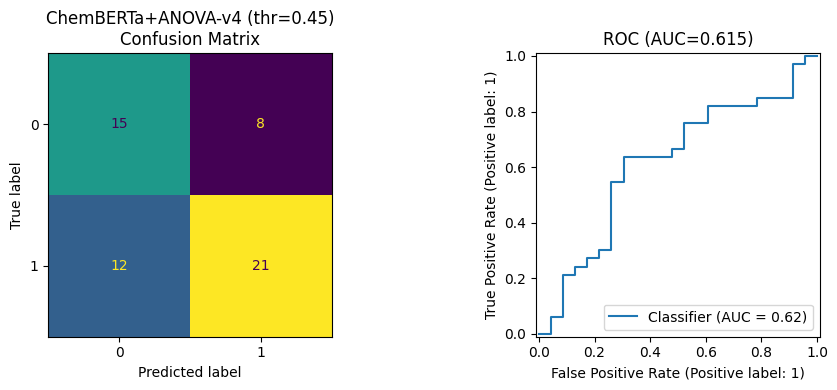

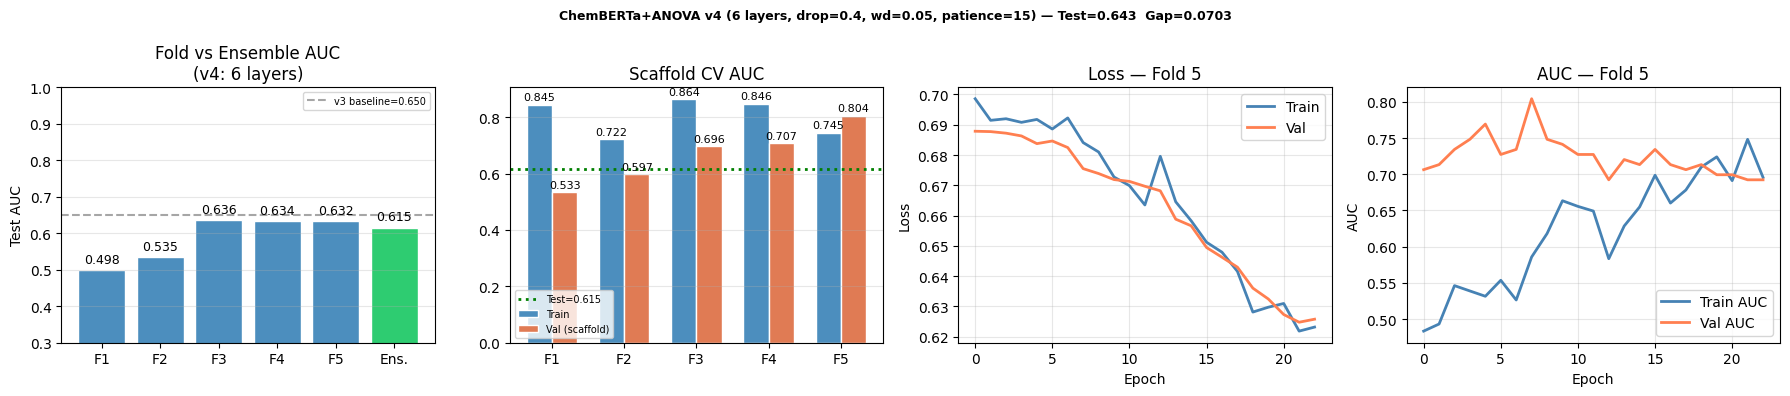


💾 Saved to Drive
   Threshold : 0.4500000000000002
  ✅ Added to results_log for Cell 17


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 16B — ChemBERTa+ANOVA (6 layers, longer training)   ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install transformers torch -q

import logging, warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModel,
                           get_linear_schedule_with_warmup)
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay,
                              RocCurveDisplay,
                              average_precision_score,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import os, pickle, shutil

print("=" * 65)
print("  ChemBERTa+ANOVA — 6 Layers, Longer Training")
print("=" * 65)

# ── Why 6 layers + longer training ───────────────────────────
# v3 result: train=0.673, test=0.696, gap=-0.023
# Negative gap = model is UNDERFIT = train < test
# This means we can add capacity safely:
#   • 6 layers (between 4=underfit, 8=overfit)
#   • patience 8 → 15 (let it run longer)
#   • epochs 60 → 80
#   • dropout 0.5 → 0.4 (slightly less reg since underfitting)
#   • weight_decay 0.1 → 0.05 (same reason)

PROJECT_DIR = "/content/drive/MyDrive/crystal_classification"
os.makedirs(PROJECT_DIR, exist_ok=True)

MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
device     = torch.device("cuda" if torch.cuda.is_available()
                           else "cpu")
print(f"  Device : {device}")

# ── full_evaluate ─────────────────────────────────────────────
results_log = results_log if "results_log" in dir() else []

def full_evaluate(model_name, y_tr, y_tr_pred,
                  y_te, y_te_pred, y_te_prob=None):
    tr_acc = accuracy_score(y_tr, y_tr_pred)
    te_acc = accuracy_score(y_te, y_te_pred)
    tr_f1  = f1_score(y_tr, y_tr_pred, average="weighted")
    te_f1  = f1_score(y_te, y_te_pred, average="weighted")
    auc    = roc_auc_score(y_te, y_te_prob) \
             if y_te_prob is not None else None
    ap     = average_precision_score(y_te, y_te_prob) \
             if y_te_prob is not None else None
    gap    = tr_acc - te_acc
    print(f"\n{'━'*62}")
    print(f"  {model_name}")
    print(f"{'━'*62}")
    print(f"  Train Accuracy     : {tr_acc:.4f}")
    print(f"  Test  Accuracy     : {te_acc:.4f}")
    print(f"  Train F1 (wt)      : {tr_f1:.4f}")
    print(f"  Test  F1 (wt)      : {te_f1:.4f}")
    if auc: print(f"  AUC-ROC            : {auc:.4f}")
    if ap:  print(f"  Avg Precision      : {ap:.4f}")
    print(f"  Overfit Gap        : {gap:.4f}  "
          + ("⚠️  Overfitting" if gap > 0.08
             else "✅ Generalised"))
    print(f"\n  Classification Report:\n"
          f"{classification_report(y_te, y_te_pred)}")
    ncols = 2 if y_te_prob is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    if ncols == 1: axes = [axes]
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_te_pred)
    ).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{model_name}\nConfusion Matrix")
    if y_te_prob is not None:
        RocCurveDisplay.from_predictions(
            y_te, y_te_prob, ax=axes[1])
        axes[1].set_title(f"ROC (AUC={auc:.3f})")
    plt.tight_layout()
    plt.show()
    results_log.append({
        "Model":     model_name,
        "Train Acc": round(tr_acc, 4),
        "Test Acc":  round(te_acc, 4),
        "Train F1":  round(tr_f1,  4),
        "Test F1":   round(te_f1,  4),
        "AUC-ROC":   round(auc, 4) if auc else "—",
        "Avg Prec":  round(ap,  4) if ap  else "—",
        "Gap":       round(gap,  4),
    })


# ── Data ──────────────────────────────────────────────────────
smiles_train = df[train_mask].reset_index(
    drop=True)["SMILES"].tolist()
smiles_test  = df[test_mask].reset_index(
    drop=True)["SMILES"].tolist()
y_tr = y_train.values.astype(np.float32)
y_te = y_test.values.astype(np.float32)

X_tr_anova = X_train_sel.astype(np.float32)
X_te_anova = X_test_sel.astype(np.float32)

print(f"\n  Train : {len(smiles_train)}  "
      f"ANOVA : {X_tr_anova.shape[1]}  "
      f"Combined : 768+{X_tr_anova.shape[1]}")


# ── Scaffold CV splits ────────────────────────────────────────
train_df        = df[train_mask].reset_index(drop=True)
train_scaffolds = train_df["scaffold"].values
unique_sc       = np.unique(train_scaffolds)
np.random.seed(42)
np.random.shuffle(unique_sc)
N_FOLDS        = 5
scaffold_folds = np.array_split(unique_sc, N_FOLDS)

scaffold_cv_splits = []
for fold_i in range(N_FOLDS):
    val_sc = scaffold_folds[fold_i]
    tr_sc  = np.concatenate([
        scaffold_folds[j] for j in range(N_FOLDS)
        if j != fold_i
    ])
    tr_idx  = np.where(np.isin(train_scaffolds, tr_sc))[0]
    val_idx = np.where(np.isin(train_scaffolds, val_sc))[0]
    scaffold_cv_splits.append((tr_idx, val_idx))

print(f"\n  Scaffold CV folds:")
for i, (tr, val) in enumerate(scaffold_cv_splits):
    print(f"  Fold {i+1}: train={len(tr)}  val={len(val)}")


# ── Dataset ───────────────────────────────────────────────────
class CombinedDataset(Dataset):
    def __init__(self, smiles_list, anova_features,
                 labels, tokenizer, max_len=128):
        self.smiles    = smiles_list
        self.anova     = torch.tensor(anova_features,
                                       dtype=torch.float32)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "anova_feats":    self.anova[idx],
            "label":          torch.tensor(
                                   self.labels[idx],
                                   dtype=torch.float32)
        }


# ── Model ─────────────────────────────────────────────────────
class CombinedClassifier(nn.Module):
    def __init__(self, model_name, n_anova=50,
                 dropout=0.4, unfreeze_last_n=6):
        super().__init__()
        self.bert = AutoModel.from_pretrained(
            model_name, ignore_mismatched_sizes=True)
        hidden = self.bert.config.hidden_size  # 768

        for param in self.bert.parameters():
            param.requires_grad = False

        total = 12
        for name, param in self.bert.named_parameters():
            for i in range(total - unfreeze_last_n, total):
                if f"layer.{i}" in name:
                    param.requires_grad = True
            if "pooler" in name:
                param.requires_grad = True

        n_trainable = sum(p.numel()
                          for p in self.bert.parameters()
                          if p.requires_grad)
        print(f"    BERT trainable: {n_trainable:,}")

        self.anova_proj = nn.Sequential(
            nn.Linear(n_anova, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, input_ids, attention_mask, anova_feats):
        out      = self.bert(input_ids=input_ids,
                             attention_mask=attention_mask)
        cls      = out.last_hidden_state[:, 0, :]
        anova_out = self.anova_proj(anova_feats)
        combined  = torch.cat([cls, anova_out], dim=1)
        return self.classifier(combined).squeeze(-1)


# ── Training ──────────────────────────────────────────────────
def train_fold(smiles_tr, anova_tr, y_tr_f,
               smiles_va, anova_va, y_va_f,
               tokenizer,
               epochs=80, batch_size=16,
               lr=1e-5, patience=15,
               dropout=0.4, unfreeze_last_n=6,
               weight_decay=0.05):

    n_anova = anova_tr.shape[1]
    ds_tr   = CombinedDataset(smiles_tr, anova_tr,
                               y_tr_f, tokenizer)
    ds_va   = CombinedDataset(smiles_va, anova_va,
                               y_va_f, tokenizer)
    dl_tr   = DataLoader(ds_tr, batch_size=batch_size,
                         shuffle=True)
    dl_va   = DataLoader(ds_va, batch_size=batch_size,
                         shuffle=False)

    model = CombinedClassifier(
        MODEL_NAME, n_anova=n_anova,
        dropout=dropout,
        unfreeze_last_n=unfreeze_last_n
    ).to(device)

    criterion = nn.BCELoss()

    bert_params  = [p for n, p in model.bert.named_parameters()
                    if p.requires_grad]
    other_params = (list(model.anova_proj.parameters()) +
                    list(model.classifier.parameters()))

    optimizer = torch.optim.AdamW([
        {"params": bert_params,  "lr": lr},
        {"params": other_params, "lr": lr * 10},
    ], weight_decay=weight_decay)

    total_steps  = epochs * len(dl_tr)
    warmup_steps = int(0.1 * total_steps)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = total_steps
    )

    best_val_auc = -np.inf
    patience_ctr = 0
    best_state   = None
    history      = {"tr_loss": [], "va_loss": [],
                    "tr_auc":  [], "va_auc":  []}

    for epoch in range(epochs):
        model.train()
        tr_loss_s = 0
        tr_preds, tr_labels = [], []

        for batch in dl_tr:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            anova = batch["anova_feats"].to(device)
            lbl   = batch["label"].to(device)

            optimizer.zero_grad()
            out  = model(ids, mask, anova)
            loss = criterion(out, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            tr_loss_s += loss.item()
            tr_preds.extend(out.detach().cpu().numpy())
            tr_labels.extend(lbl.cpu().numpy())

        model.eval()
        va_loss_s = 0
        va_preds, va_labels = [], []

        with torch.no_grad():
            for batch in dl_va:
                ids   = batch["input_ids"].to(device)
                mask  = batch["attention_mask"].to(device)
                anova = batch["anova_feats"].to(device)
                lbl   = batch["label"].to(device)
                out   = model(ids, mask, anova)
                loss  = criterion(out, lbl)
                va_loss_s += loss.item()
                va_preds.extend(out.cpu().numpy())
                va_labels.extend(lbl.cpu().numpy())

        tr_auc  = roc_auc_score(tr_labels, tr_preds)
        va_auc  = roc_auc_score(va_labels, va_preds)
        tr_loss = tr_loss_s / len(dl_tr)
        va_loss = va_loss_s / len(dl_va)

        history["tr_loss"].append(tr_loss)
        history["va_loss"].append(va_loss)
        history["tr_auc"].append(tr_auc)
        history["va_auc"].append(va_auc)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"    Epoch {epoch+1:3d}: "
                  f"tr={tr_auc:.4f}  va={va_auc:.4f}  "
                  f"gap={tr_auc-va_auc:+.4f}  "
                  f"patience={patience_ctr}/{patience}")

        if va_auc > best_val_auc:
            best_val_auc = va_auc
            patience_ctr = 0
            best_state   = {k: v.clone()
                            for k, v in
                            model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"    Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    print(f"    Best val AUC : {best_val_auc:.4f}")
    return model, history


# ── Prediction ────────────────────────────────────────────────
def predict(model, smiles_list, anova_feats,
            y_labels, tokenizer, batch_size=32):
    ds = CombinedDataset(smiles_list, anova_feats,
                          y_labels, tokenizer)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in dl:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            anova = batch["anova_feats"].to(device)
            out   = model(ids, mask, anova)
            probs.extend(out.cpu().numpy())
    return np.array(probs)


# ══════════════════════════════════════════════════════════════
# SCAFFOLD CV — 6 layers, 80 epochs, patience=15
# ══════════════════════════════════════════════════════════════
print("\n  Training (6 layers, 80 epochs, patience=15) ...\n")

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
smiles_arr = np.array(smiles_train)

train_aucs      = []
val_aucs        = []
fold_ckpts      = []
fold_test_probs = []
valid_folds     = []
fold_histories  = []

for fold, (tr_idx, val_idx) in enumerate(scaffold_cv_splits):

    print(f"\n{'─'*55}")
    print(f"  Fold {fold+1}/5  "
          f"(train={len(tr_idx)}, val={len(val_idx)})")
    print(f"{'─'*55}")

    smiles_tr_f = smiles_arr[tr_idx].tolist()
    smiles_va_f = smiles_arr[val_idx].tolist()
    anova_tr_f  = X_tr_anova[tr_idx]
    anova_va_f  = X_tr_anova[val_idx]
    y_tr_f      = y_tr[tr_idx]
    y_va_f      = y_tr[val_idx]

    if len(np.unique(y_va_f)) < 2:
        print(f"  Fold {fold+1}: skipped (single class)")
        continue

    model, history = train_fold(
        smiles_tr_f, anova_tr_f, y_tr_f,
        smiles_va_f, anova_va_f, y_va_f,
        tokenizer,
        epochs          = 80,
        batch_size      = 16,
        lr              = 1e-5,
        patience        = 15,
        dropout         = 0.4,
        unfreeze_last_n = 6,
        weight_decay    = 0.05,
    )

    ckpt_f = f"{PROJECT_DIR}/combined_v4_fold_{fold}.pt"
    torch.save(model.state_dict(), ckpt_f)
    fold_ckpts.append(ckpt_f)

    tr_probs   = predict(model, smiles_tr_f, anova_tr_f,
                          y_tr_f, tokenizer)
    va_probs   = predict(model, smiles_va_f, anova_va_f,
                          y_va_f, tokenizer)
    test_probs = predict(model, smiles_test, X_te_anova,
                          y_te, tokenizer)

    tr_auc = roc_auc_score(y_tr_f, tr_probs)
    va_auc = roc_auc_score(y_va_f, va_probs)

    train_aucs.append(tr_auc)
    val_aucs.append(va_auc)
    fold_test_probs.append(test_probs)
    valid_folds.append(fold + 1)
    fold_histories.append(history)

    print(f"\n  Fold {fold+1}: "
          f"train={tr_auc:.4f}  val={va_auc:.4f}  "
          f"gap={tr_auc-va_auc:+.4f}  "
          f"test={roc_auc_score(y_te, test_probs):.4f}")

mean_train_auc = np.mean(train_aucs)
mean_val_auc   = np.mean(val_aucs)
gap_cv         = mean_train_auc - mean_val_auc

print(f"\n{'═'*55}")
print(f"  Scaffold CV Train AUC : {mean_train_auc:.4f}")
print(f"  Scaffold CV Val   AUC : {mean_val_auc:.4f}")
print(f"  Scaffold CV Gap       : {gap_cv:.4f}")

if gap_cv > 0.08:
    print("⚠️  Overfitting")
elif gap_cv > 0.03:
    print("⚠️  Mild Overfitting")
else:
    print("✅ No Significant Overfitting")


# ── Ensemble ──────────────────────────────────────────────────
print("\n  Ensembling ...")
ensemble_probs = np.mean(np.vstack(fold_test_probs), axis=0)

fold_train_probs_all = []
for ckpt_f in fold_ckpts:
    m_load = CombinedClassifier(
        MODEL_NAME,
        n_anova=X_tr_anova.shape[1],
        dropout=0.4,
        unfreeze_last_n=6
    ).to(device)
    m_load.load_state_dict(
        torch.load(ckpt_f, map_location=device))
    p = predict(m_load, smiles_train, X_tr_anova,
                y_tr, tokenizer)
    fold_train_probs_all.append(p)

ensemble_train_probs = np.mean(
    np.vstack(fold_train_probs_all), axis=0)

thr_recs = [
    (t,
     f1_score(y_te, (ensemble_probs >= t).astype(int),
              average="weighted"),
     accuracy_score(y_te,
                    (ensemble_probs >= t).astype(int)))
    for t in np.arange(0.25, 0.76, 0.01)
]
best_thr     = max(thr_recs, key=lambda x: x[1])[0]
y_pred_test  = (ensemble_probs       >= best_thr).astype(int)
y_pred_train = (ensemble_train_probs >= best_thr).astype(int)

tr_acc    = accuracy_score(y_tr, y_pred_train)
te_acc    = accuracy_score(y_te, y_pred_test)
te_f1     = f1_score(y_te, y_pred_test, average="weighted")
te_auc    = roc_auc_score(y_te, ensemble_probs)
gap_final = tr_acc - te_acc

print(f"\n  Optimal threshold  : {best_thr:.2f}")
print(f"  Train Accuracy     : {tr_acc:.4f}")
print(f"  Test  Accuracy     : {te_acc:.4f}")
print(f"  Test  F1           : {te_f1:.4f}")
print(f"  Test  AUC-ROC      : {te_auc:.4f}")
print(f"  Overfit Gap        : {gap_final:.4f}  "
      + ("⚠️  Overfitting" if gap_final > 0.08
         else "✅ Generalised"))
print(f"\n  Scaffold CV Val AUC : {mean_val_auc:.4f}")
print(f"  Scaffold CV Gap     : {gap_cv:.4f}")
print(f"\n  Previous best (v3)  : test=0.6964")
print(f"  This version  (v4)  : test={te_acc:.4f}  "
      + ("✅ Improved" if te_acc > 0.6964 else
         "↔ Same" if abs(te_acc - 0.6964) < 0.01 else
         "↓ Worse — use v3"))


# ── Full evaluation ───────────────────────────────────────────
full_evaluate(
    f"ChemBERTa+ANOVA-v4 (thr={best_thr:.2f})",
    y_tr, y_pred_train,
    y_te, y_pred_test,
    y_te_prob = ensemble_probs,
)


# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

fold_test_aucs = [roc_auc_score(y_te, p)
                  for p in fold_test_probs]
lbls  = [f"F{i}" for i in valid_folds] + ["Ens."]
aucs_ = fold_test_aucs + [te_auc]
clrs_ = ["#4c8ebe"] * len(valid_folds) + ["#2ecc71"]
bars  = axes[0].bar(lbls, aucs_, color=clrs_,
                     edgecolor="white")
axes[0].bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
axes[0].axhline(0.6495, color="grey", linestyle="--",
                alpha=0.7, label="v3 baseline=0.650")
axes[0].set_ylim(0.3, 1.0)
axes[0].set_ylabel("Test AUC")
axes[0].set_title("Fold vs Ensemble AUC\n(v4: 6 layers)")
axes[0].legend(fontsize=7)
axes[0].grid(axis="y", alpha=0.3)

x_ = np.arange(len(valid_folds))
w_ = 0.35
b1 = axes[1].bar(x_ - w_/2, train_aucs, w_,
                  color="#4c8ebe", label="Train",
                  edgecolor="white")
b2 = axes[1].bar(x_ + w_/2, val_aucs, w_,
                  color="#e07b54", label="Val (scaffold)",
                  edgecolor="white")
axes[1].bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
axes[1].bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
axes[1].axhline(te_auc, color="green", linestyle=":",
                lw=2, label=f"Test={te_auc:.3f}")
axes[1].set_xticks(x_)
axes[1].set_xticklabels([f"F{i}" for i in valid_folds])
axes[1].set_title("Scaffold CV AUC")
axes[1].legend(fontsize=7)
axes[1].grid(axis="y", alpha=0.3)

if fold_histories:
    last_h = fold_histories[-1]
    axes[2].plot(last_h["tr_loss"], color="steelblue",
                 lw=2, label="Train")
    axes[2].plot(last_h["va_loss"], color="coral",
                 lw=2, label="Val")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title(f"Loss — Fold {valid_folds[-1]}")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(last_h["tr_auc"], color="steelblue",
                 lw=2, label="Train AUC")
    axes[3].plot(last_h["va_auc"], color="coral",
                 lw=2, label="Val AUC")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("AUC")
    axes[3].set_title(f"AUC — Fold {valid_folds[-1]}")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

plt.suptitle(
    f"ChemBERTa+ANOVA v4 (6 layers, drop=0.4, wd=0.05, "
    f"patience=15) — "
    f"Test={te_acc:.3f}  Gap={gap_final:.4f}",
    fontsize=9, fontweight="bold"
)
plt.tight_layout()
plt.show()


# ── Save ──────────────────────────────────────────────────────
with open(f"{PROJECT_DIR}/combined_v4_threshold.pkl",
          "wb") as f:
    pickle.dump(best_thr, f)

for i, ckpt_f in enumerate(fold_ckpts):
    shutil.copy(
        ckpt_f,
        f"{PROJECT_DIR}/combined_v4_fold_"
        f"{valid_folds[i]}.pt"
    )

results_log.append({
    "Model":     f"ChemBERTa+ANOVA-v4 (thr={best_thr:.2f})",
    "Train Acc": round(tr_acc, 4),
    "Test Acc":  round(te_acc, 4),
    "Train F1":  round(
        f1_score(y_tr, y_pred_train, average="weighted"), 4),
    "Test F1":   round(te_f1,  4),
    "AUC-ROC":   round(te_auc, 4),
    "Avg Prec":  "—",
    "Gap":       round(gap_final, 4),
})

print("\n💾 Saved to Drive")
print(f"   Threshold : {best_thr}")
print(f"  ✅ Added to results_log for Cell 17")